In [1]:
import os
import json
import time
import argparse
from typing import Tuple, Optional
import re

import numpy as np
from scipy.optimize import minimize

#few and SEF imports
from few.waveform import GenerateEMRIWaveform
from few.waveform.waveform import SuperKludgeWaveform, FastKerrEccentricEquatorialAccretionFlux

from few.trajectory.inspiral import EMRIInspiral
from few.trajectory.ode.flux import KerrEccEqFlux, SuperKludgeFlux
from few.utils.geodesic import get_fundamental_frequencies
from scipy.interpolate import CubicSpline
from scipy.integrate import cumulative_trapezoid
from few.utils.constants import YRSID_SI

from few.utils.constants import MTSUN_SI
from few.utils.utility import get_p_at_t
from few.utils.geodesic import get_separatrix


from fastlisaresponse import ResponseWrapper
from lisatools.detector import EqualArmlengthOrbits
from lisatools.sensitivity import get_sensitivity, A1TDISens, E1TDISens, T1TDISens
from stableemrifisher.utils import generate_PSD, inner_product, fishinv
from stableemrifisher.fisher import StableEMRIFisher
import matplotlib.pyplot as plt
import corner

try:
    import cupy as cp
    cp.cuda.runtime.getDeviceCount()      # importing cupy is not enough, the driver must work too
    xp, use_gpu = cp, True
except Exception as exc:
    xp, use_gpu = np, False
    print(f"[INFO] No usable GPU ({type(exc).__name__}), falling back to NumPy on CPU.")

print(f"[INFO] use_gpu = {use_gpu}")

startup
[INFO] use_gpu = True


In [2]:
def evolve_inspiral(m1, m2, a, p0, e0,T_obs, xI0=1.0 ,
                        flux_class=KerrEccEqFlux, add_args=(), full=False):


        traj = EMRIInspiral(func=flux_class)
        # KerrEccEqFlux returns t + 6 arrays, SuperKludgeFlux returns t + 8
        # (it also evolves delta_m1, delta_a), so unpack by position not by count.
        out_traj = traj(m1, m2, a, p0, e0, xI0, *add_args, T=T_obs)
        t, p, e, xI = out_traj[0], out_traj[1], out_traj[2], out_traj[3]
        Phi_phi, Phi_r, Phi_theta = out_traj[4], out_traj[5], out_traj[6]

        sep = float(get_separatrix(a, e[-1], xI0))
        t_yr = float(t[-1]) / YRSID_SI
        # plunge = the integrator stopped at the separatrix rather than at T_obs
        plunged = bool(t_yr < 0.999 * T_obs)
        try:
            p0_plunge = float(get_p_at_t(traj, T_obs, [m1, m2, a, e0, xI0] + list(add_args),
                                         bounds=None))
        except Exception:
            p0_plunge = float("nan")

        out = dict(e0=float(e0), e_final=float(e[-1]),
                   p0=float(p0), p_final=float(p[-1]),
                   separatrix=sep, dp_to_separatrix=float(p[-1]) - sep,
                   t_final_yr=t_yr, plunged=plunged, p0_for_plunge=p0_plunge,
                   n_points=int(len(t)))
        if full:
            out.update(t=t, p=p, e=e, xI=xI, Phi_phi=Phi_phi, Phi_r=Phi_r)
        return out

## 1. Source parameters and the environmental deviation

`SuperKludgeFlux` on the `environ_shubham` branch takes 12 extra arguments after the usual 14:

```
0  chi2                    5  C_p                       8  A_PM
1  evolve_1PA              6  C_e                       9  n_PM
2  evolve_primary          7  environmental_included   10  A_GC
3  evolve_2PA                                          11  n_GC
4  deviation_included
```

`environmental_included` gates a multiplicative correction to `Ldot` only (`Edot` is left at GR):

$$\dot L = \dot L_{\rm GR}\left(1 + A_{\rm PM}\left(\tfrac{p}{10M}\right)^{n_{\rm PM}} F_m + A_{\rm GC}\left(\tfrac{p}{M}\right)^{n_{\rm GC}}\right), \qquad F_m = 1 \;\;(m=0)$$

In [ ]:
a = 0.9
m2 = 50
Phi_phi0 = 0.3
qS = .2
phiS = 0.2
qK = 0.8
phiK = 0.8
dist = 1.5
Phi_theta0 = 0.5
Phi_r0 = 0.5
e0 = 0.2
Y0 = 1.0

#sample random m1 between 1e6 and 1e7. For now, just use 1.5e6
m1 = 1.5e6

# SuperKludge tail: everything off except the environmental block.
chi2 = 0.0
evolve_1PA = False
evolve_primary = False
evolve_2PA = False
deviation_included = False
dev_PN_p = 0.0
dev_PN_e = 0.0

# environmental coefficients
A_PM = 1.92e-5 * (m1 / 1e6)
n_PM = 8.0
A_GC = 1e-12
n_GC = 4.0
A_GC = 0
n_GC = 0


# select p0 such that time of observation is between 3 and 4
p0 = 12
print(f"[ENV] A_PM = {A_PM:.6e}, n_PM = {n_PM}, A_GC = {A_GC:.6e}, n_GC = {n_GC}")
print(f"[ENV] Ldot rescaling at p0 = {p0}: "
      f"{1 + A_PM * (p0 / 10) ** n_PM + A_GC * p0 ** n_GC:.12f}")

[ENV] A_PM = 2.880000e-05, n_PM = 8.0, A_GC = 0.000000e+00, n_GC = 0
[ENV] Ldot rescaling at p0 = 12: 1.000123834728


## 2. Parameter vectors: GR vs environmental

In [ ]:
param_names_14 = ["m1", "m2", "a", "p0", "e0", "xI0", "dist", "qS", "phiS",
                  "qK", "phiK", "Phi_phi0", "Phi_theta0", "Phi_r0"]

source_params = dict(m1=m1, m2=m2, a=a, p0=p0, e0=e0, xI0=Y0, dist=dist,
                     qS=qS, phiS=phiS, qK=qK, phiK=phiK,
                     Phi_phi0=Phi_phi0, Phi_theta0=Phi_theta0, Phi_r0=Phi_r0)


def env_tail(environmental_included):
    """The 12 extra SuperKludgeFlux arguments, positional, as ResponseWrapper wants them."""
    return [chi2, evolve_1PA, evolve_primary, evolve_2PA,
            deviation_included, dev_PN_p, dev_PN_e,
            environmental_included, A_PM, n_PM, A_GC, n_GC]


def env_apa(environmental_included):
    """The same 12 arguments as a dict, which is how SEF wants them (appended in dict order)."""
    return dict(chi2=chi2, evolve_1PA=evolve_1PA, evolve_primary=evolve_primary,
                evolve_2PA=evolve_2PA, deviation_included=deviation_included,
                C_p=dev_PN_p, C_e=dev_PN_e,
                environmental_included=environmental_included,
                A_PM=A_PM, n_PM=n_PM, A_GC=A_GC, n_GC=n_GC)


def wave_params(environmental_included):
    return [source_params[n] for n in param_names_14] + env_tail(environmental_included)


print("[GR ]", wave_params(False))
print("[ENV]", wave_params(True))

[GR ] [1500000.0, 50, 0.9, 12, 0.2, 1.0, 1.5, 0.2, 0.2, 0.8, 0.8, 0.3, 0.5, 0.5, 0.0, False, False, False, False, 0.0, 0.0, False, 2.88e-05, 8.0, 0, 0]
[ENV] [1500000.0, 50, 0.9, 12, 0.2, 1.0, 1.5, 0.2, 0.2, 0.8, 0.8, 0.3, 0.5, 0.5, 0.0, False, False, False, False, 0.0, 0.0, True, 2.88e-05, 8.0, 0, 0]


## 3. Observation window: run to plunge

In [5]:
# The test runs to plunge, so T comes from the trajectory rather than being hardcoded.
# T_SAFETY < 1 backs off a hair from the separatrix: at exactly T = t_plunge, the Fisher
# stencil steps that increase m2 plunge before T and SEF's plunge_check rejects them.
# Set T_SAFETY = 1.0 to sit exactly at plunge.
T_SAFETY = 0.99

insp_gr = evolve_inspiral(m1, m2, a, p0, e0, T_obs=10.0, xI0=Y0,
                          flux_class=SuperKludgeFlux, add_args=env_tail(False))
T_plunge = insp_gr["t_final_yr"]
T = T_SAFETY * T_plunge

dt = 5
nchannels = 2

# Inner products are restricted to this band. Everything -- overlap, SNR, both Fishers --
# uses the same mask, so the two cases are scored identically.
F_MIN, F_MAX = 1e-5, 1e-1

print(f"[TRAJ] plunged = {insp_gr['plunged']}, t_plunge = {T_plunge:.6f} yr, "
      f"p_final = {insp_gr['p_final']:.5f}, separatrix = {insp_gr['separatrix']:.5f}")
print(f"[CONF] T = {T:.6f} yr ({T_SAFETY:g} x t_plunge), dt = {dt} s, nchannels = {nchannels}")
print(f"[CONF] Nyquist = {1 / (2 * dt):.4f} Hz, N samples ~ {int(T * YRSID_SI / dt):,d}")
print(f"[CONF] band = [{F_MIN:.1e}, {F_MAX:.1e}] Hz"
      + ("  -- f_max is at or above Nyquist, so the upper edge does nothing"
         if F_MAX >= 1 / (2 * dt) else ""))

[TRAJ] plunged = True, t_plunge = 3.373095 yr, p_final = 2.38790, separatrix = 2.33790
[CONF] T = 3.339364 yr (0.99 x t_plunge), dt = 5 s, nchannels = 2
[CONF] Nyquist = 0.1000 Hz, N samples ~ 21,076,828
[CONF] band = [1.0e-05, 1.0e-01] Hz  -- f_max is at or above Nyquist, so the upper edge does nothing


## 4. Waveform + LISA response

In [ ]:
def build_waveform_response(T, dt, use_gpu=False, tdi_chan="AET"):
    sum_kwargs = dict(pad_output=True, odd_len=True)
    waveform_model = GenerateEMRIWaveform(SuperKludgeWaveform, sum_kwargs=sum_kwargs,
                                          return_list=False, use_gpu=use_gpu)
    t0 = 10000.0
    tdi_gen = "1st generation"
    order = 20
    index_lambda = 8  # phiS
    index_beta = 7    # qS
    response = ResponseWrapper(
        waveform_gen=waveform_model,
        Tobs=T,
        t0=t0,
        dt=dt,
        index_lambda=index_lambda,
        index_beta=index_beta,
        flip_hx=True,
        is_ecliptic_latitude=False,
        remove_garbage="zero",
        orbits=EqualArmlengthOrbits(use_gpu=use_gpu),
        force_backend="cuda12x" if use_gpu else "cpu",
        order=order,
        tdi=tdi_gen,
        tdi_chan=tdi_chan)
    return response


# SEF builds its own ResponseWrapper internally, so keep one dict and reuse it for both.
response_kwargs = dict(
    Tobs=T, t0=10000.0, dt=dt, index_lambda=8, index_beta=7, flip_hx=True,
    is_ecliptic_latitude=False, remove_garbage="zero",
    orbits=EqualArmlengthOrbits(use_gpu=use_gpu),
    force_backend="cuda12x" if use_gpu else "cpu",
    order=20, tdi="1st generation", tdi_chan={2: "AE", 3: "AET"}[nchannels])

waveform_response = build_waveform_response(T=T, dt=dt, use_gpu=use_gpu,
                                            tdi_chan=response_kwargs["tdi_chan"])
print("[INFO] response built")

[INFO] response built


## 5. The two waveforms, PSD and SNRs

In [7]:
t_start = time.time()
waveform_gr = xp.array(waveform_response(*wave_params(False)))[0:nchannels, :]
waveform_env = xp.array(waveform_response(*wave_params(True)))[0:nchannels, :]
print(f"[INFO] both waveforms generated in {time.time() - t_start:.1f} s")

channels = [A1TDISens, E1TDISens, T1TDISens]
if nchannels == 3:
    noise_kwargs = [{"sens_fn": ch} for ch in channels]
elif nchannels == 2:
    noise_kwargs = [{"sens_fn": ch} for ch in channels[:2]]
else:
    raise ValueError(f"Unsupported number of channels: {nchannels}. Only 2 (A,E) or 3 (A,E,T) are supported.")

# PSD is built once, from the GR waveform, and used for both so the two are scored identically.
PSD_funcs = generate_PSD(
    waveform=waveform_gr,
    dt=dt,
    noise_PSD=get_sensitivity,
    channels=channels[:nchannels],
    noise_kwargs=noise_kwargs,
    use_gpu=use_gpu,
)
PSD_funcs_ = xp.array(PSD_funcs)
print("shape check - waveform:", xp.shape(waveform_gr), "PSD_funcs:", xp.shape(PSD_funcs_))


def make_freq_mask(n, dt, fmin, fmax):
    """Boolean mask over rfftfreq with the DC bin dropped, which is what inner_product wants."""
    f = xp.fft.rfftfreq(n, dt)
    return ((f > fmin) & (f < fmax))[1:]


N_fiducial = len(waveform_gr[0])
assert waveform_env.shape == waveform_gr.shape, "the two waveforms must be the same length to share a mask"
freq_mask = make_freq_mask(N_fiducial, dt, F_MIN, F_MAX)


def ip(a, b):
    v = inner_product(a, b, PSD_funcs_, dt, freq_mask=freq_mask, use_gpu=use_gpu)
    return float(v.get() if hasattr(v, "get") else v)


for label, h in [("GR ", waveform_gr), ("ENV", waveform_env)]:
    snr = np.sqrt(ip(h, h))
    print(f"[{label}] SNR: {snr:.6f}")
    for i in range(nchannels):
        v = inner_product(h[i:i + 1, ], h[i:i + 1, ], PSD_funcs_[i:i + 1, :], dt,
                          freq_mask=freq_mask, use_gpu=use_gpu)
        snr_i = np.sqrt(float(v.get() if hasattr(v, "get") else v))
        print(f"[{label}] SNR - Channel {i}: {snr_i:.6f}  ({100 * (snr_i / snr) ** 2:.2f}% of SNR^2)")

freq = np.fft.rfftfreq(N_fiducial, dt)
delta_f = freq[1] - freq[0]
n_kept = int(freq_mask.sum().get() if hasattr(freq_mask.sum(), "get") else freq_mask.sum())
print(f"[INFO] Frequency resolution delta_f: {delta_f:.6e} Hz, Number of frequency bins: {len(freq)}")
print(f"freq_max: {freq[-1]:.6f} Hz and Freq_min: {freq[1]:.6f} Hz")
print(f"[MASK] band [{F_MIN:.1e}, {F_MAX:.1e}] Hz keeps {n_kept:,d} / {len(freq) - 1:,d} bins "
      f"({100 * n_kept / (len(freq) - 1):.2f}%)")

[INFO] both waveforms generated in 12.9 s
shape check - waveform: (2, 21076828) PSD_funcs: (2, 10538414)
[GR ] SNR: 374.788377
[GR ] SNR - Channel 0: 252.317500  (45.32% of SNR^2)
[GR ] SNR - Channel 1: 277.132110  (54.68% of SNR^2)
[ENV] SNR: 348.576415
[ENV] SNR - Channel 0: 252.684974  (52.55% of SNR^2)
[ENV] SNR - Channel 1: 240.116266  (47.45% of SNR^2)
[INFO] Frequency resolution delta_f: 9.489094e-09 Hz, Number of frequency bins: 10538415
freq_max: 0.100000 Hz and Freq_min: 0.000000 Hz
[MASK] band [1.0e-05, 1.0e-01] Hz keeps 10,537,360 / 10,538,414 bins (99.99%)


## 6. Overlap between the two waveforms

In [8]:
snr_gr = np.sqrt(ip(waveform_gr, waveform_gr))
snr_env = np.sqrt(ip(waveform_env, waveform_env))
overlap = ip(waveform_gr, waveform_env) / (snr_gr * snr_env)
mismatch = 1.0 - overlap

# chi2 of the residual, the same quantity the CV runs report
resid = waveform_env - waveform_gr
chi2_resid = ip(resid, resid)

print(f"[OVL] SNR_GR   = {snr_gr:.6f}")
print(f"[OVL] SNR_ENV  = {snr_env:.6f}")
print(f"[OVL] overlap  = {overlap:.12f}")
print(f"[OVL] mismatch = {mismatch:.6e}")
print(f"[OVL] chi2 <r|r>          = {chi2_resid:.6e}")
print(f"[OVL] 2 SNR^2 (1-overlap) = {2 * snr_gr * snr_env * mismatch:.6e}   (consistency check)")

# where the difference comes from: accumulated orbital dephasing
traj = EMRIInspiral(func=SuperKludgeFlux)
out_gr = traj(m1, m2, a, p0, e0, Y0, *env_tail(False), T=T)
out_env = traj(m1, m2, a, p0, e0, Y0, *env_tail(True), T=T)
t_common = min(out_gr[0][-1], out_env[0][-1])
dPhi_phi = float(CubicSpline(out_env[0], out_env[4])(t_common) - CubicSpline(out_gr[0], out_gr[4])(t_common))
dPhi_r = float(CubicSpline(out_env[0], out_env[5])(t_common) - CubicSpline(out_gr[0], out_gr[5])(t_common))
print(f"[DEPH] dPhi_phi = {dPhi_phi:+.6e} rad over {t_common / YRSID_SI:.6f} yr "
      f"(total Phi_phi = {out_gr[4][-1]:.1f} rad)")
print(f"[DEPH] dPhi_r   = {dPhi_r:+.6e} rad")

[OVL] SNR_GR   = 374.788377
[OVL] SNR_ENV  = 348.576415
[OVL] overlap  = 0.499934006830
[OVL] mismatch = 5.000660e-01
[OVL] chi2 <r|r>          = 1.313467e+05
[OVL] 2 SNR^2 (1-overlap) = 1.306596e+05   (consistency check)
[DEPH] dPhi_phi = +6.262711e-01 rad over 3.339364 yr (total Phi_phi = 496614.4 rad)
[DEPH] dPhi_r   = +5.484049e-01 rad


## 7. Fisher and covariance for both cases

Same 9 parameters for both, so the two covariances live on identical axes and can be
overlaid directly.

In [ ]:
# we do not need it in the main code for analysis, but it is useful for plotting and labelling the Fisher matrix results.
PARAMS_9 = ["m1", "m2", "a", "p0", "e0", "qS", "phiS", "Phi_phi0", "Phi_r0"]
LABELS_9 = [r"$\Delta m_1$", r"$\Delta m_2$", r"$\Delta a$", r"$\Delta p_0$", r"$\Delta e_0$",
            r"$\Delta \theta_S$", r"$\Delta \phi_S$", r"$\Delta \Phi_{\varphi 0}$", r"$\Delta \Phi_{r 0}$"]

NDELTA = 12
DER_ORDER = 8

sef = StableEMRIFisher(
    waveform_class=SuperKludgeWaveform,
    waveform_class_kwargs=dict(sum_kwargs=dict(pad_output=True, odd_len=True)),
    waveform_generator=GenerateEMRIWaveform,
    waveform_generator_kwargs=dict(return_list=False),
    ResponseWrapper=ResponseWrapper, ResponseWrapper_kwargs=response_kwargs,
    stats_for_nerds=False, use_gpu=use_gpu, deriv_type="stable",
    noise_model=get_sensitivity, noise_kwargs=noise_kwargs, channels=channels[:nchannels],
    T=T, dt=dt, stability_plot=False, der_order=DER_ORDER, Ndelta=NDELTA,
    plunge_check=True, return_derivatives=False)


def fisher_for(environmental_included, label):
    t_start = time.time()
    F = sef(wave_params=source_params, param_names=PARAMS_9,
            add_param_args=env_apa(environmental_included),
            freq_mask=freq_mask,          # same band as the overlaps above
            live_dangerously=False, stability_plot=False,
            der_order=DER_ORDER, Ndelta=NDELTA)
    F = np.asarray(F, dtype=float)
    F = 0.5 * (F + F.T)                       # symmetrise away round-off
    print(f"[FISH] {label}: shape {F.shape}, cond = {np.linalg.cond(F):.3e}, "
          f"{time.time() - t_start:.1f} s")
    return F


fisher_gr = fisher_for(False, "GR ")
fisher_env = fisher_for(True, "ENV")

Body is not plunging, Fisher should be stable.
waveform shape: (2, 21076828)
Computing SNR for parameters: (1500000.0, 50, 0.9, 12, 0.2, 1.0, 1.5, 0.2, 0.2, 0.8, 0.8, 0.3, 0.5, 0.5, 0.0, False, False, False, False, 0.0, 0.0, False, 2.88e-05, 8.0, 0, 0)
Waveform Generated. SNR: 374.7883766504489
calculating stable deltas...
Time taken to compute stable deltas is 53.5182318687439 seconds
calculating Fisher matrix...
Finished derivatives
Calculated Fisher is *atleast* positive-definite.
Time taken to compute FM is 5.06856369972229 seconds
[FISH] GR : shape (9, 9), cond = 1.142e+18, 61.7 s
Body is not plunging, Fisher should be stable.
waveform shape: (2, 21076828)
Computing SNR for parameters: (1500000.0, 50, 0.9, 12, 0.2, 1.0, 1.5, 0.2, 0.2, 0.8, 0.8, 0.3, 0.5, 0.5, 0.0, False, False, False, False, 0.0, 0.0, True, 2.88e-05, 8.0, 0, 0)
Waveform Generated. SNR: 348.57641487872644
calculating stable deltas...
Time taken to compute stable deltas is 52.88521695137024 seconds
calculating Fishe

In [10]:
def covariance_of(F):
    """fishinv rescales m1 -> ln m1 before inverting, which is what makes this invertible."""
    C = fishinv(source_params["m1"], F, index_of_M=PARAMS_9.index("m1"))
    C = 0.5 * (C + C.T)
    evals = np.linalg.eigvalsh(C)
    if evals.min() <= 0:
        print(f"[WARN] covariance is not positive definite, min eigenvalue = {evals.min():.3e}")
    return C


cov_gr = covariance_of(fisher_gr)
cov_env = covariance_of(fisher_env)

sigma_gr = np.sqrt(np.diag(cov_gr))
sigma_env = np.sqrt(np.diag(cov_env))

print(f"{'param':>10} | {'sigma GR':>14} | {'sigma ENV':>14} | {'ratio ENV/GR':>12}")
print("-" * 60)
for i, p in enumerate(PARAMS_9):
    print(f"{p:>10} | {sigma_gr[i]:>14.6e} | {sigma_env[i]:>14.6e} | {sigma_env[i] / sigma_gr[i]:>12.5f}")

     param |       sigma GR |      sigma ENV | ratio ENV/GR
------------------------------------------------------------
        m1 |   2.608837e+00 |   2.235514e+00 |      0.85690
        m2 |   3.031329e-05 |   2.669253e-05 |      0.88056
         a |   1.317521e-06 |   1.108017e-06 |      0.84099
        p0 |   1.144988e-05 |   9.811012e-06 |      0.85687
        e0 |   1.046491e-06 |   9.158143e-07 |      0.87513
        qS |   1.067999e-03 |   6.086197e-04 |      0.56987
      phiS |   5.322005e-03 |   1.534268e-03 |      0.28829
  Phi_phi0 |   1.616381e-02 |   1.560198e-02 |      0.96524
    Phi_r0 |   1.924055e-02 |   1.898159e-02 |      0.98654


## 8. Overlaid corner plot

[PLOT] written corner_env_vs_gr.png


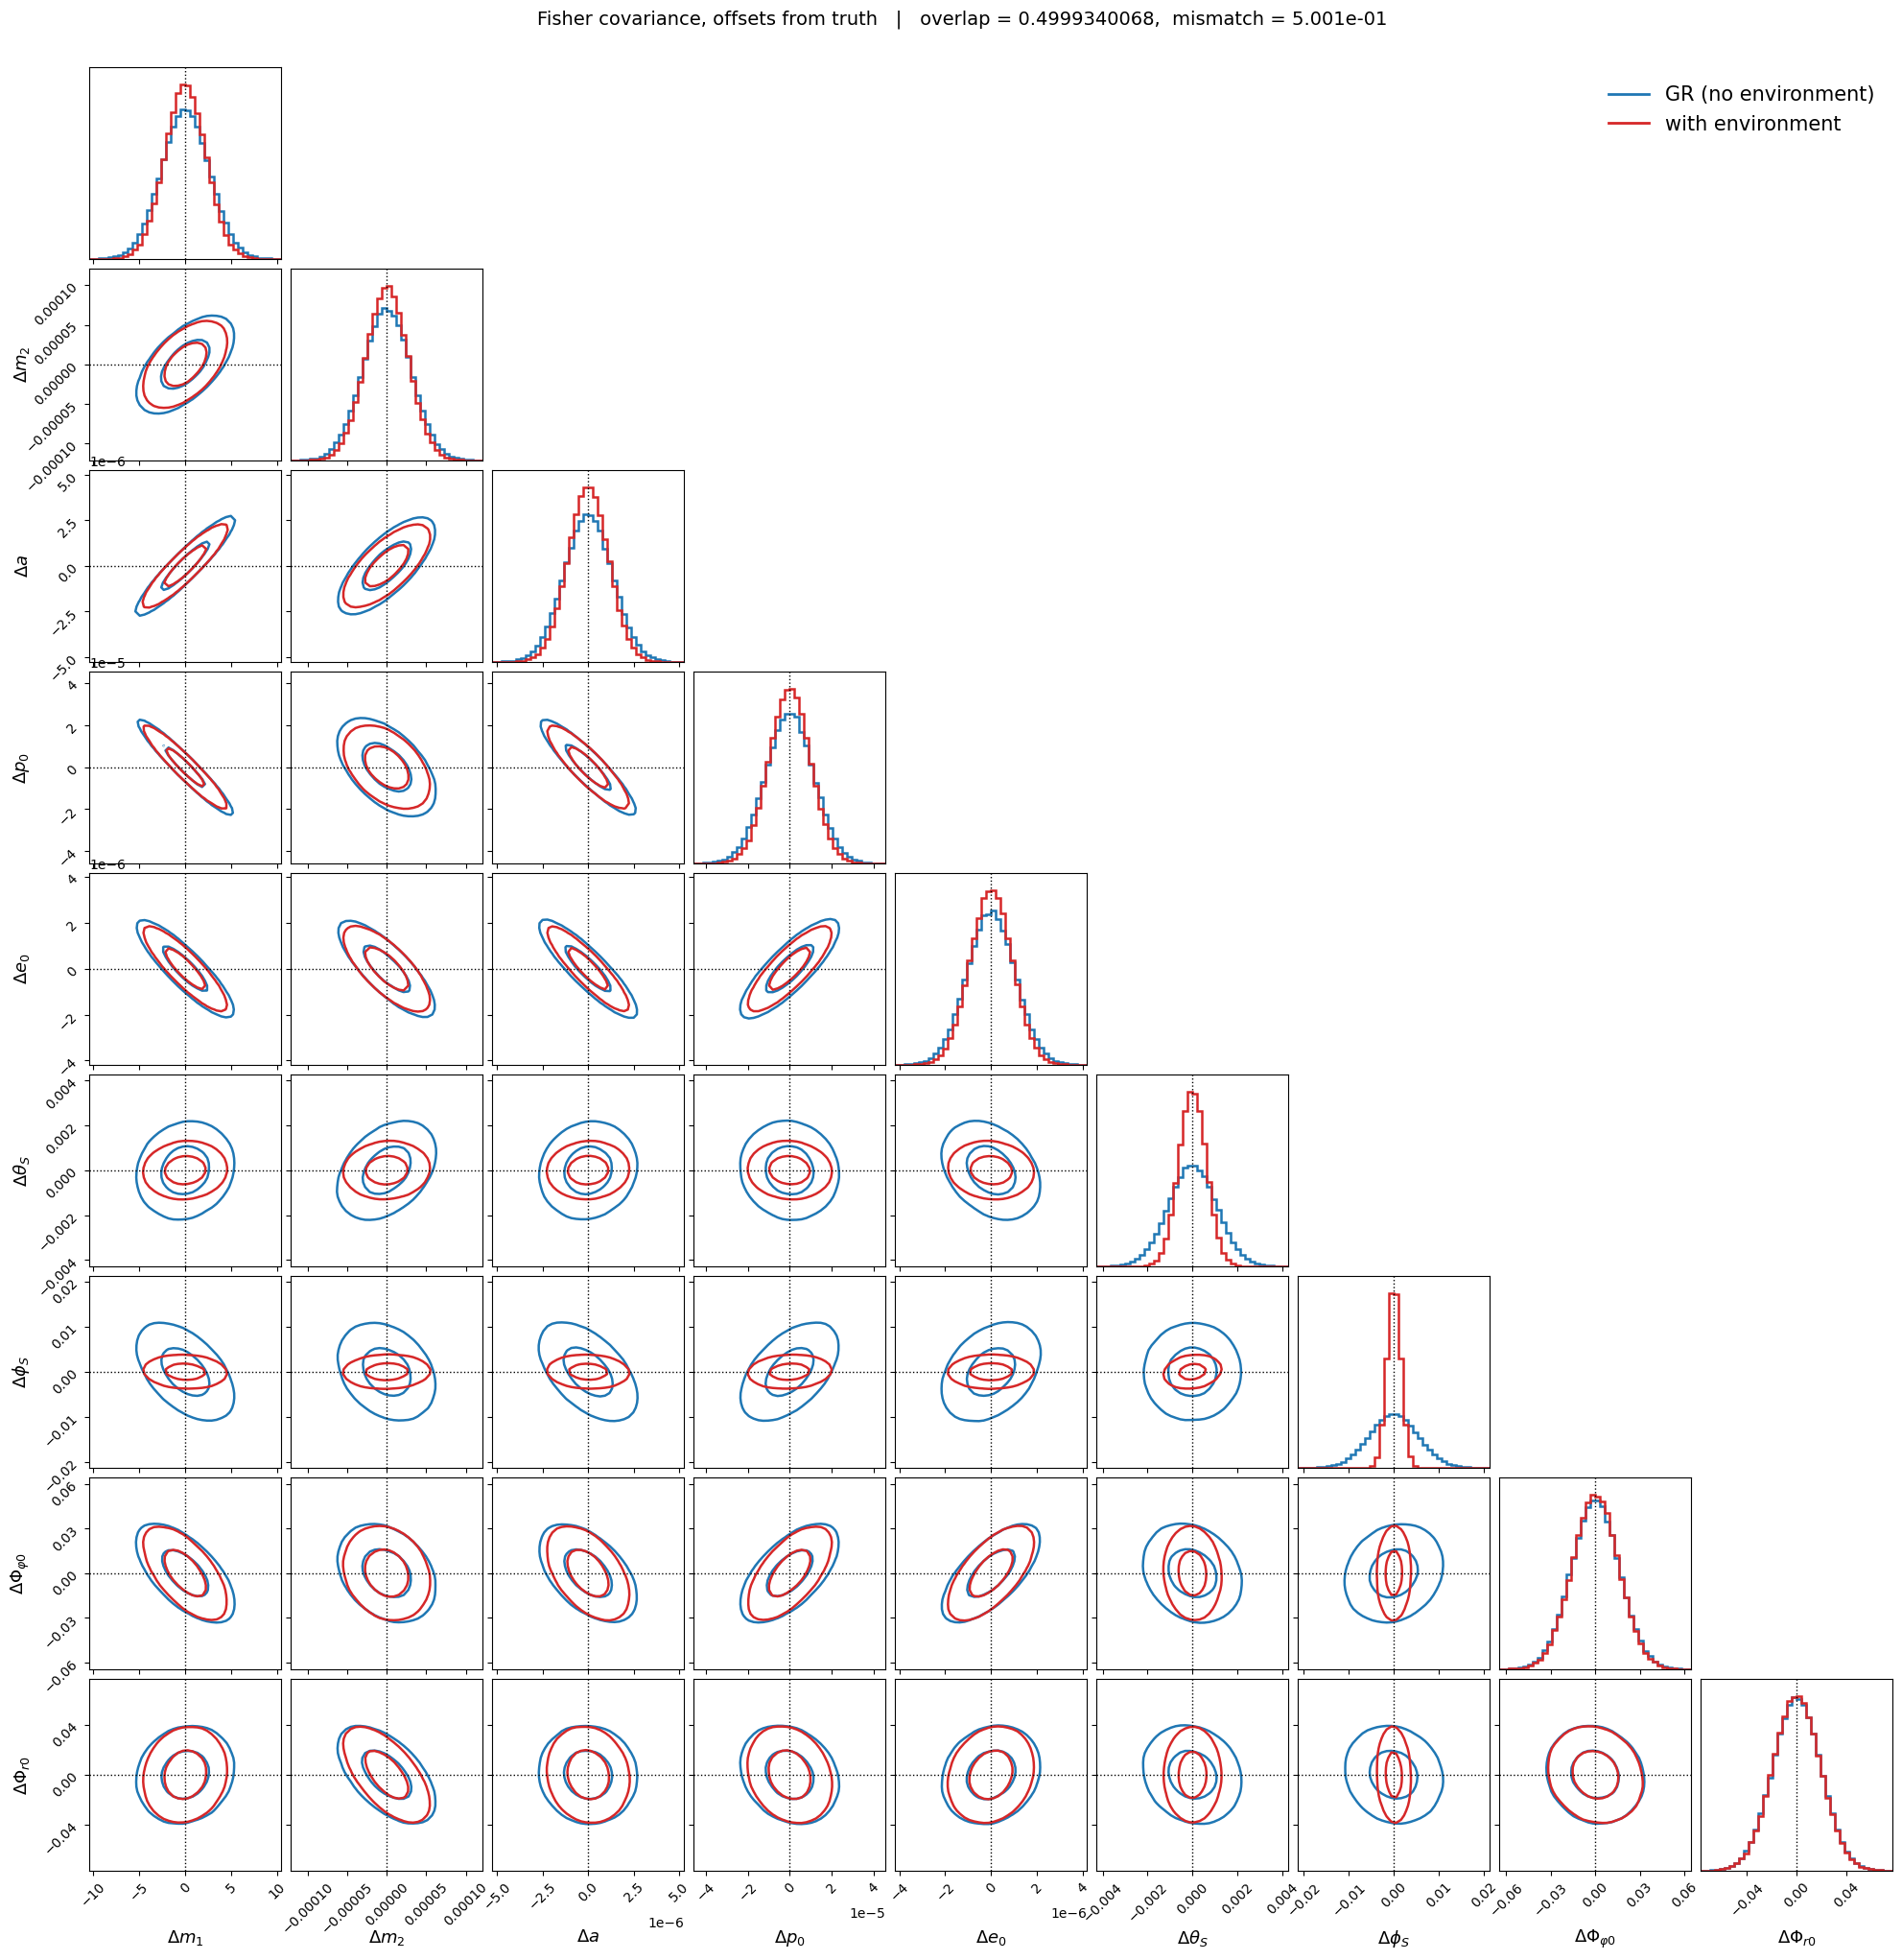

In [11]:
NSAMP = 200000
rng = np.random.default_rng(42)

# Sample the two Gaussians centred on zero, i.e. plot the offset from the true value.
# The parameters differ by ~10 orders of magnitude in scale, so absolute axes are unreadable.
draw_gr = rng.multivariate_normal(np.zeros(len(PARAMS_9)), cov_gr, size=NSAMP)
draw_env = rng.multivariate_normal(np.zeros(len(PARAMS_9)), cov_env, size=NSAMP)

# Same axis ranges for both, so the two contour sets are directly comparable.
span = 4.0 * np.maximum(sigma_gr, sigma_env)
plot_range = [(-s, s) for s in span]


def corner_kwargs(color):
    # corner mutates hist_kwargs / contour_kwargs in place to inject the colour, so these
    # have to be freshly built per call or the second set silently comes out the first colour.
    return dict(
        labels=LABELS_9, range=plot_range,
        levels=(0.393, 0.865),           # 1 sigma and 2 sigma in 2D
        smooth=1.0, bins=40, color=color,
        plot_datapoints=False, plot_density=False, fill_contours=False,
        hist_kwargs=dict(density=True, lw=1.8, color=color),
        contour_kwargs=dict(linewidths=1.8, colors=color),
        label_kwargs=dict(fontsize=13),
    )


fig = corner.corner(draw_gr, **corner_kwargs("C0"))
corner.corner(draw_env, fig=fig, **corner_kwargs("C3"))

# mark the truth (offset zero) on every panel
corner.overplot_lines(fig, np.zeros(len(PARAMS_9)), color="k", ls=":", lw=1.0)

handles = [plt.Line2D([], [], color="C0", lw=2, label="GR (no environment)"),
           plt.Line2D([], [], color="C3", lw=2, label="with environment")]
fig.legend(handles=handles, loc="upper right", frameon=False, fontsize=15,
           bbox_to_anchor=(0.98, 0.98))
fig.suptitle(f"Fisher covariance, offsets from truth   |   overlap = {overlap:.10f},  "
             f"mismatch = {mismatch:.3e}", fontsize=14, y=1.01)

fig.savefig("corner_env_vs_gr.png", dpi=140, bbox_inches="tight")
print("[PLOT] written corner_env_vs_gr.png")
plt.show()

## 9. Fisher with the environmental parameters free

Section 7 holds `A_PM, n_PM, A_GC, n_GC` fixed, so the environmental case is never charged
for the extra physics it carries and its errors can come out *smaller* than GR's. Here they
go into `param_names` instead and are marginalized over, which is the comparison made in
[arXiv:2312.13028](https://arxiv.org/abs/2312.13028) (eq. 13 there is the model in `flux.py`).
Marginalized errors are `>= 1` times the fixed-parameter ones for every parameter, by
Cauchy interlacing; how far above 1 is the degeneracy between the environment and the vacuum.

In [12]:
# A_GC = 1e-12 with the GC term going as p^n_GC: at p0 ~ 11 that is a fractional flux change
# of order 1e-8, so its derivative column is numerically dead and freeing it makes the Fisher
# singular. Free the PM pair only. Add "A_GC", "n_GC" here to attempt the joint PM+GC case.
ENV_FREE = ["A_PM", "n_PM"]

ENV_LABELS = {"A_PM": r"$\Delta A_{\rm PM}$", "n_PM": r"$\Delta n_{\rm PM}$",
              "A_GC": r"$\Delta A_{\rm GC}$", "n_GC": r"$\Delta n_{\rm GC}$"}
env_fid = dict(A_PM=A_PM, n_PM=n_PM, A_GC=A_GC, n_GC=n_GC)

PARAMS_ENV = PARAMS_9 + ENV_FREE
LABELS_ENV = LABELS_9 + [ENV_LABELS[p] for p in ENV_FREE]

# env_apa(True) already carries the fiducial values; SEF matches the free ones by name.
t_start = time.time()
F = sef(wave_params=source_params, param_names=PARAMS_ENV,
        add_param_args=env_apa(True),
        freq_mask=freq_mask,
        live_dangerously=False, stability_plot=False,
        der_order=DER_ORDER, Ndelta=NDELTA)
fisher_env_free = np.asarray(F, dtype=float)
fisher_env_free = 0.5 * (fisher_env_free + fisher_env_free.T)
print(f"[FISH] ENV, free {ENV_FREE}: shape {fisher_env_free.shape}, "
      f"cond = {np.linalg.cond(fisher_env_free):.3e}, {time.time() - t_start:.1f} s")

Body is not plunging, Fisher should be stable.
waveform shape: (2, 21076828)


Computing SNR for parameters: (1500000.0, 50, 0.9, 12, 0.2, 1.0, 1.5, 0.2, 0.2, 0.8, 0.8, 0.3, 0.5, 0.5, 0.0, False, False, False, False, 0.0, 0.0, True, 2.88e-05, 8.0, 0, 0)
Waveform Generated. SNR: 348.57641487872644
calculating stable deltas...
Time taken to compute stable deltas is 63.399619579315186 seconds
calculating Fisher matrix...
Finished derivatives
Calculated Fisher is *atleast* positive-definite.
Time taken to compute FM is 6.173511981964111 seconds
[FISH] ENV, free ['A_PM', 'n_PM']: shape (11, 11), cond = 3.379e+19, 72.7 s


In [13]:
def cov_precond(F):
    """Jacobi-preconditioned inverse: rescale every parameter by 1/sqrt(F_ii) before inverting,
    then undo. Algebraically exact, and unlike fishinv (which only rescales m1) it copes with
    A_PM ~ 1e-5 sitting in the same matrix as m1 ~ 1e6."""
    d = np.sqrt(np.diag(F))
    if np.any(d <= 0):
        raise ValueError(f"non-positive Fisher diagonal at {np.where(d <= 0)[0]}: a derivative column is dead")
    C = np.linalg.inv(F / np.outer(d, d)) / np.outer(d, d)
    return 0.5 * (C + C.T)


cov_env_free = cov_precond(fisher_env_free)

# Slicing the *inverse* is the marginalization: no extra step is needed.
n9 = len(PARAMS_9)
cov_env_marg = cov_env_free[:n9, :n9]
sigma_env_marg = np.sqrt(np.diag(cov_env_marg))

# Redo the GR covariance with the same inverter, so the ratio is not an artefact of two methods.
cov_gr_p = cov_precond(fisher_gr)
sigma_gr_p = np.sqrt(np.diag(cov_gr_p))
print(f"[CHECK] max |sigma_GR(precond) / sigma_GR(fishinv) - 1| = "
      f"{np.max(np.abs(sigma_gr_p / sigma_gr - 1)):.3e}   (should be tiny)")

print(f"\n{'param':>10} | {'sigma GR':>13} | {'ENV fixed':>13} | {'ENV marg':>13} | "
      f"{'marg/GR':>9} | {'marg/fixed':>10}")
print("-" * 86)
for i, p in enumerate(PARAMS_9):
    print(f"{p:>10} | {sigma_gr_p[i]:>13.6e} | {sigma_env[i]:>13.6e} | {sigma_env_marg[i]:>13.6e} | "
          f"{sigma_env_marg[i] / sigma_gr_p[i]:>9.4f} | {sigma_env_marg[i] / sigma_env[i]:>10.4f}")

print(f"\n{'env param':>10} | {'fiducial':>13} | {'sigma':>13} | {'value/sigma':>12}")
print("-" * 56)
sigma_env_own = np.sqrt(np.diag(cov_env_free))[n9:]
for p, s in zip(ENV_FREE, sigma_env_own):
    v = env_fid[p]
    print(f"{p:>10} | {v:>13.6e} | {s:>13.6e} | {abs(v) / s:>12.4f}")

[CHECK] max |sigma_GR(precond) / sigma_GR(fishinv) - 1| = 2.980e-10   (should be tiny)

     param |      sigma GR |     ENV fixed |      ENV marg |   marg/GR | marg/fixed
--------------------------------------------------------------------------------------
        m1 |  2.608837e+00 |  2.235514e+00 |  6.517462e+00 |    2.4982 |     2.9154
        m2 |  3.031329e-05 |  2.669253e-05 |  1.132737e-04 |    3.7368 |     4.2436
         a |  1.317521e-06 |  1.108017e-06 |  3.048776e-06 |    2.3140 |     2.7516
        p0 |  1.144988e-05 |  9.811012e-06 |  2.409962e-05 |    2.1048 |     2.4564
        e0 |  1.046491e-06 |  9.158143e-07 |  4.076706e-06 |    3.8956 |     4.4515
        qS |  1.067999e-03 |  6.086197e-04 |  6.142449e-04 |    0.5751 |     1.0092
      phiS |  5.322005e-03 |  1.534268e-03 |  1.544015e-03 |    0.2901 |     1.0064
  Phi_phi0 |  1.616381e-02 |  1.560198e-02 |  2.686157e-02 |    1.6618 |     1.7217
    Phi_r0 |  1.924055e-02 |  1.898159e-02 |  2.580361e-02 |    1.341

[PLOT] written corner_env_marginalized.png


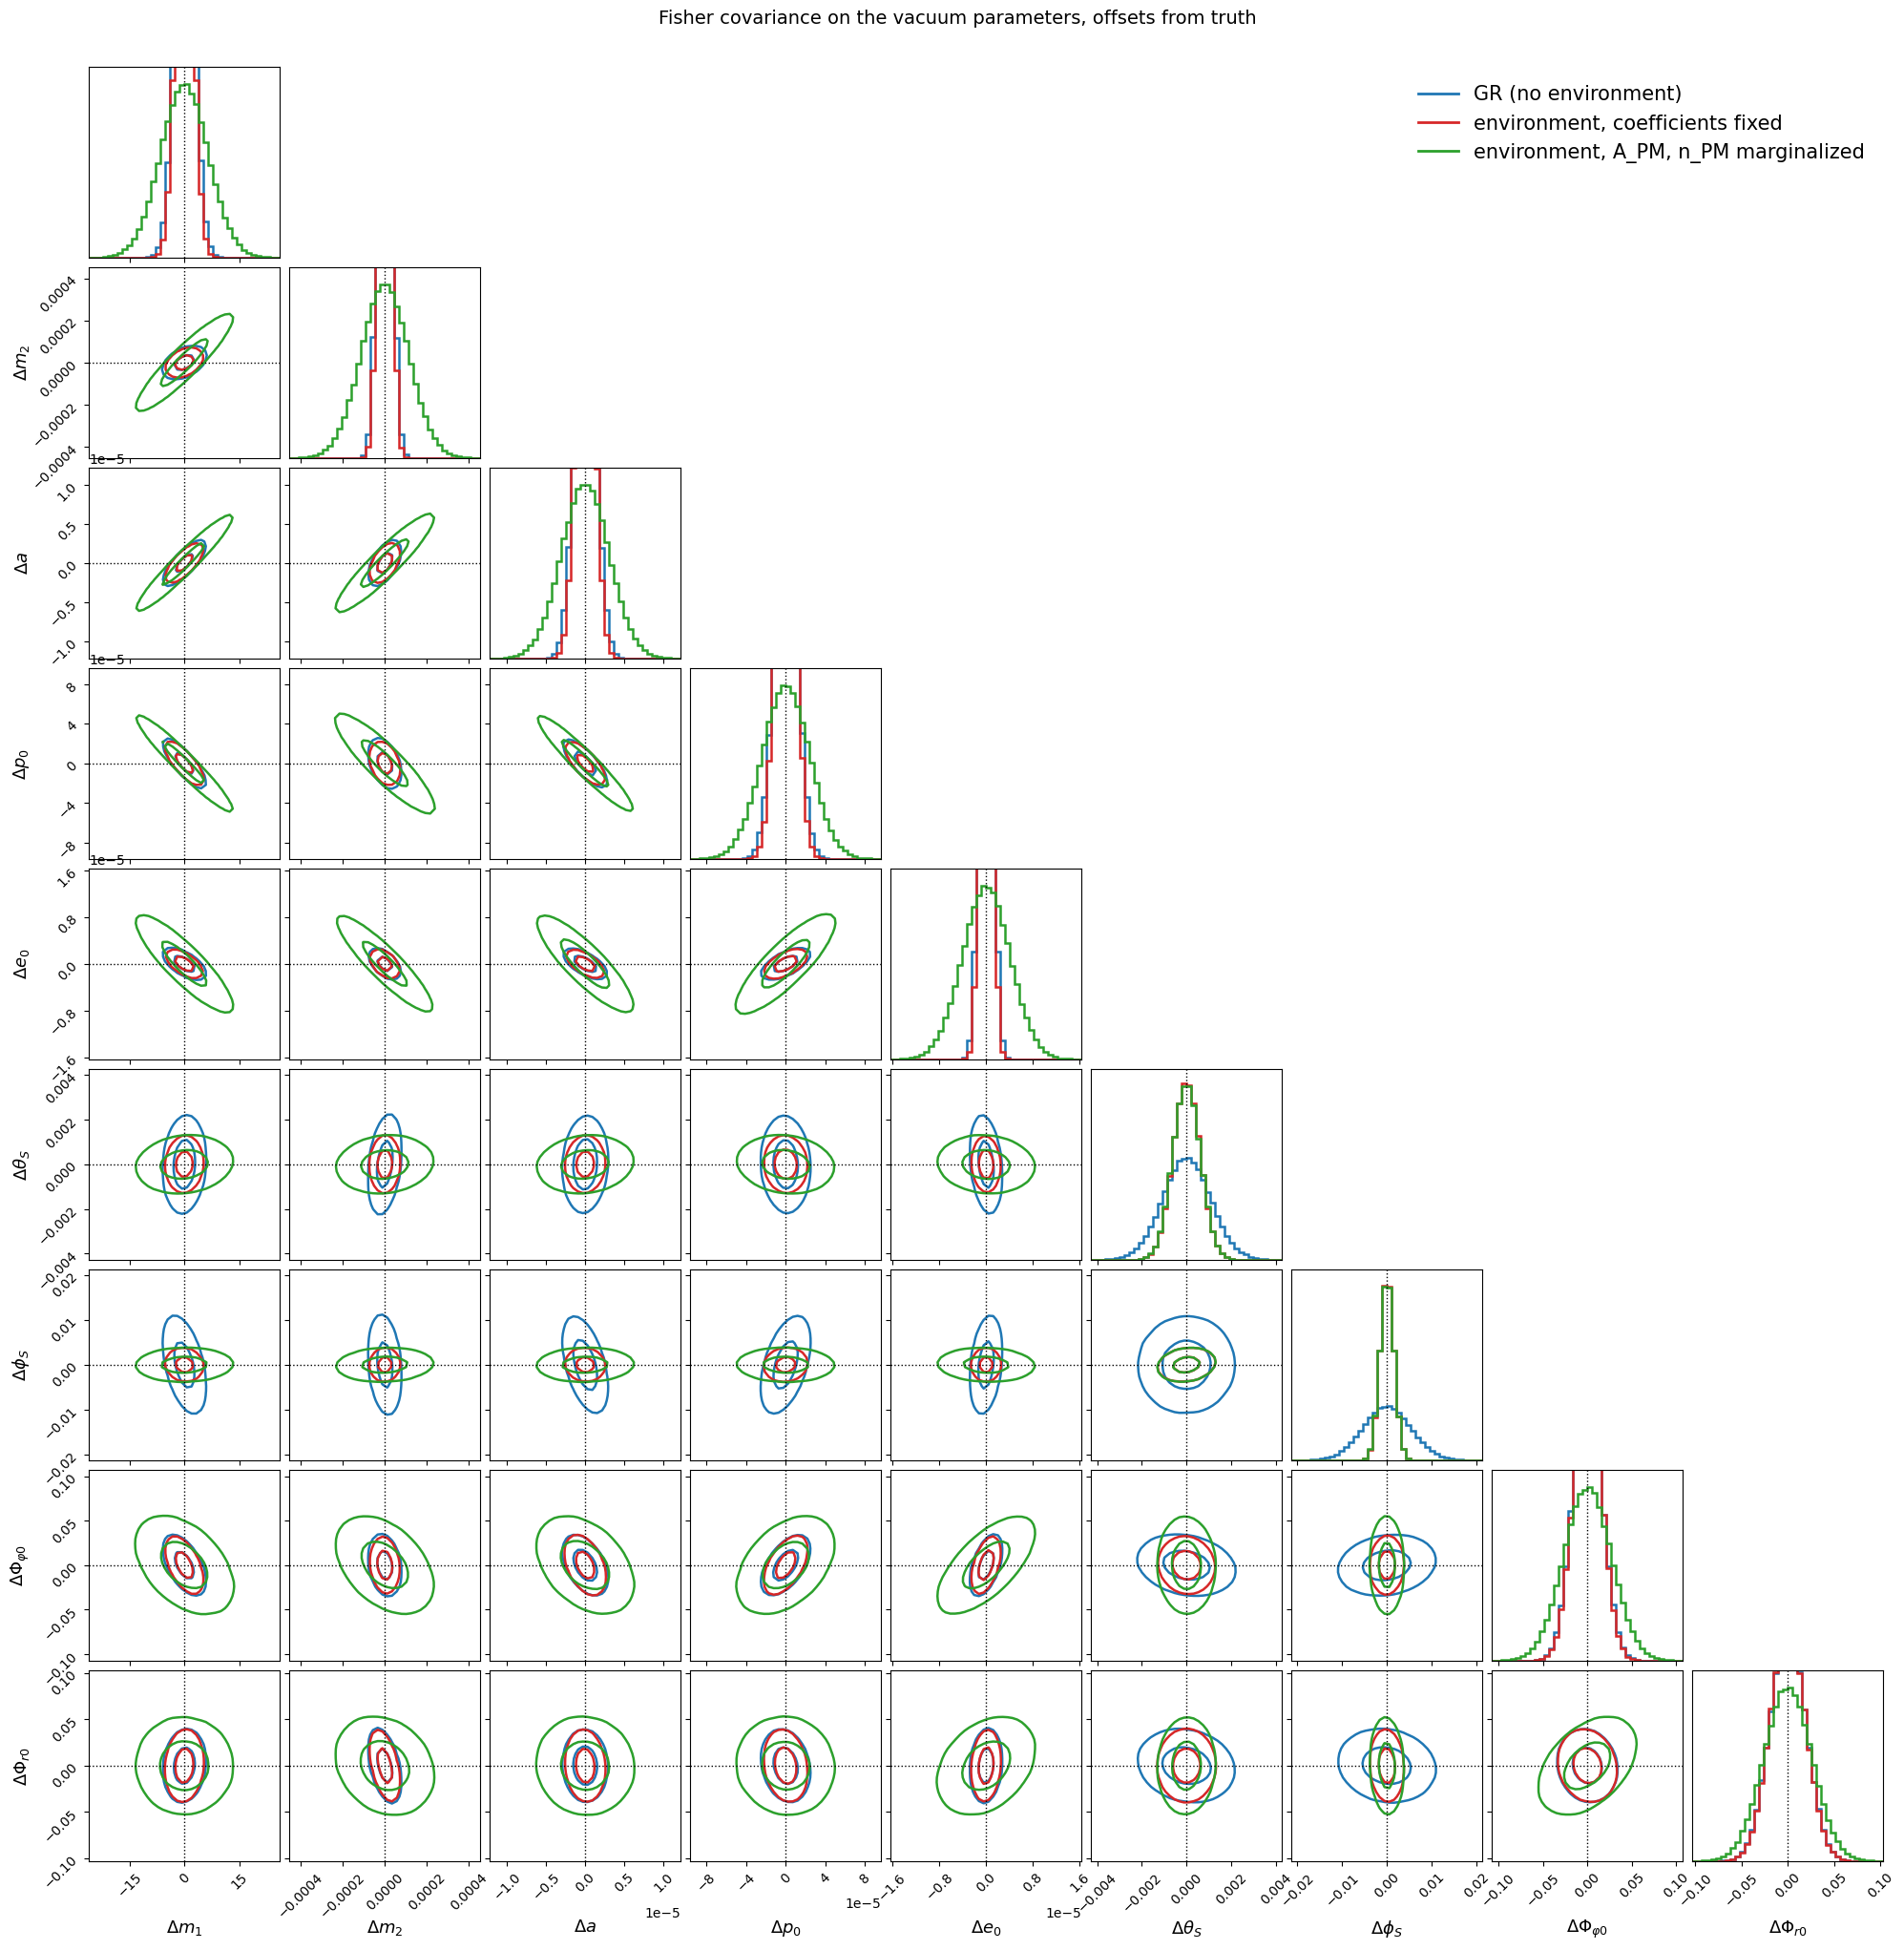

In [14]:
# Three contour sets on the same axes: GR, environment with its coefficients held fixed
# (section 8), and environment with them marginalized over. The first two are the plot above;
# the third is the one that answers "does the environment cost us measurement precision".
draw_marg = rng.multivariate_normal(np.zeros(n9), cov_env_marg, size=NSAMP)

span3 = 4.0 * np.maximum.reduce([sigma_gr_p, sigma_env, sigma_env_marg])
range3 = [(-s, s) for s in span3]


def kw3(color):
    # fresh dict per call: corner writes `color` into hist_kwargs/contour_kwargs in place.
    return dict(labels=LABELS_9, range=range3, levels=(0.393, 0.865),
                smooth=1.0, bins=40, color=color,
                plot_datapoints=False, plot_density=False, fill_contours=False,
                hist_kwargs=dict(density=True, lw=1.8, color=color),
                contour_kwargs=dict(linewidths=1.8, colors=color),
                label_kwargs=dict(fontsize=13))


fig = corner.corner(draw_gr, **kw3("C0"))
corner.corner(draw_env, fig=fig, **kw3("C3"))
corner.corner(draw_marg, fig=fig, **kw3("C2"))
corner.overplot_lines(fig, np.zeros(n9), color="k", ls=":", lw=1.0)

handles = [plt.Line2D([], [], color="C0", lw=2, label="GR (no environment)"),
           plt.Line2D([], [], color="C3", lw=2, label="environment, coefficients fixed"),
           plt.Line2D([], [], color="C2", lw=2, label=f"environment, {', '.join(ENV_FREE)} marginalized")]
fig.legend(handles=handles, loc="upper right", frameon=False, fontsize=15,
           bbox_to_anchor=(0.98, 0.98))
fig.suptitle("Fisher covariance on the vacuum parameters, offsets from truth", fontsize=14, y=1.01)

fig.savefig("corner_env_marginalized.png", dpi=140, bbox_inches="tight")
print("[PLOT] written corner_env_marginalized.png")
plt.show()

[PLOT] written corner_env_joint.png


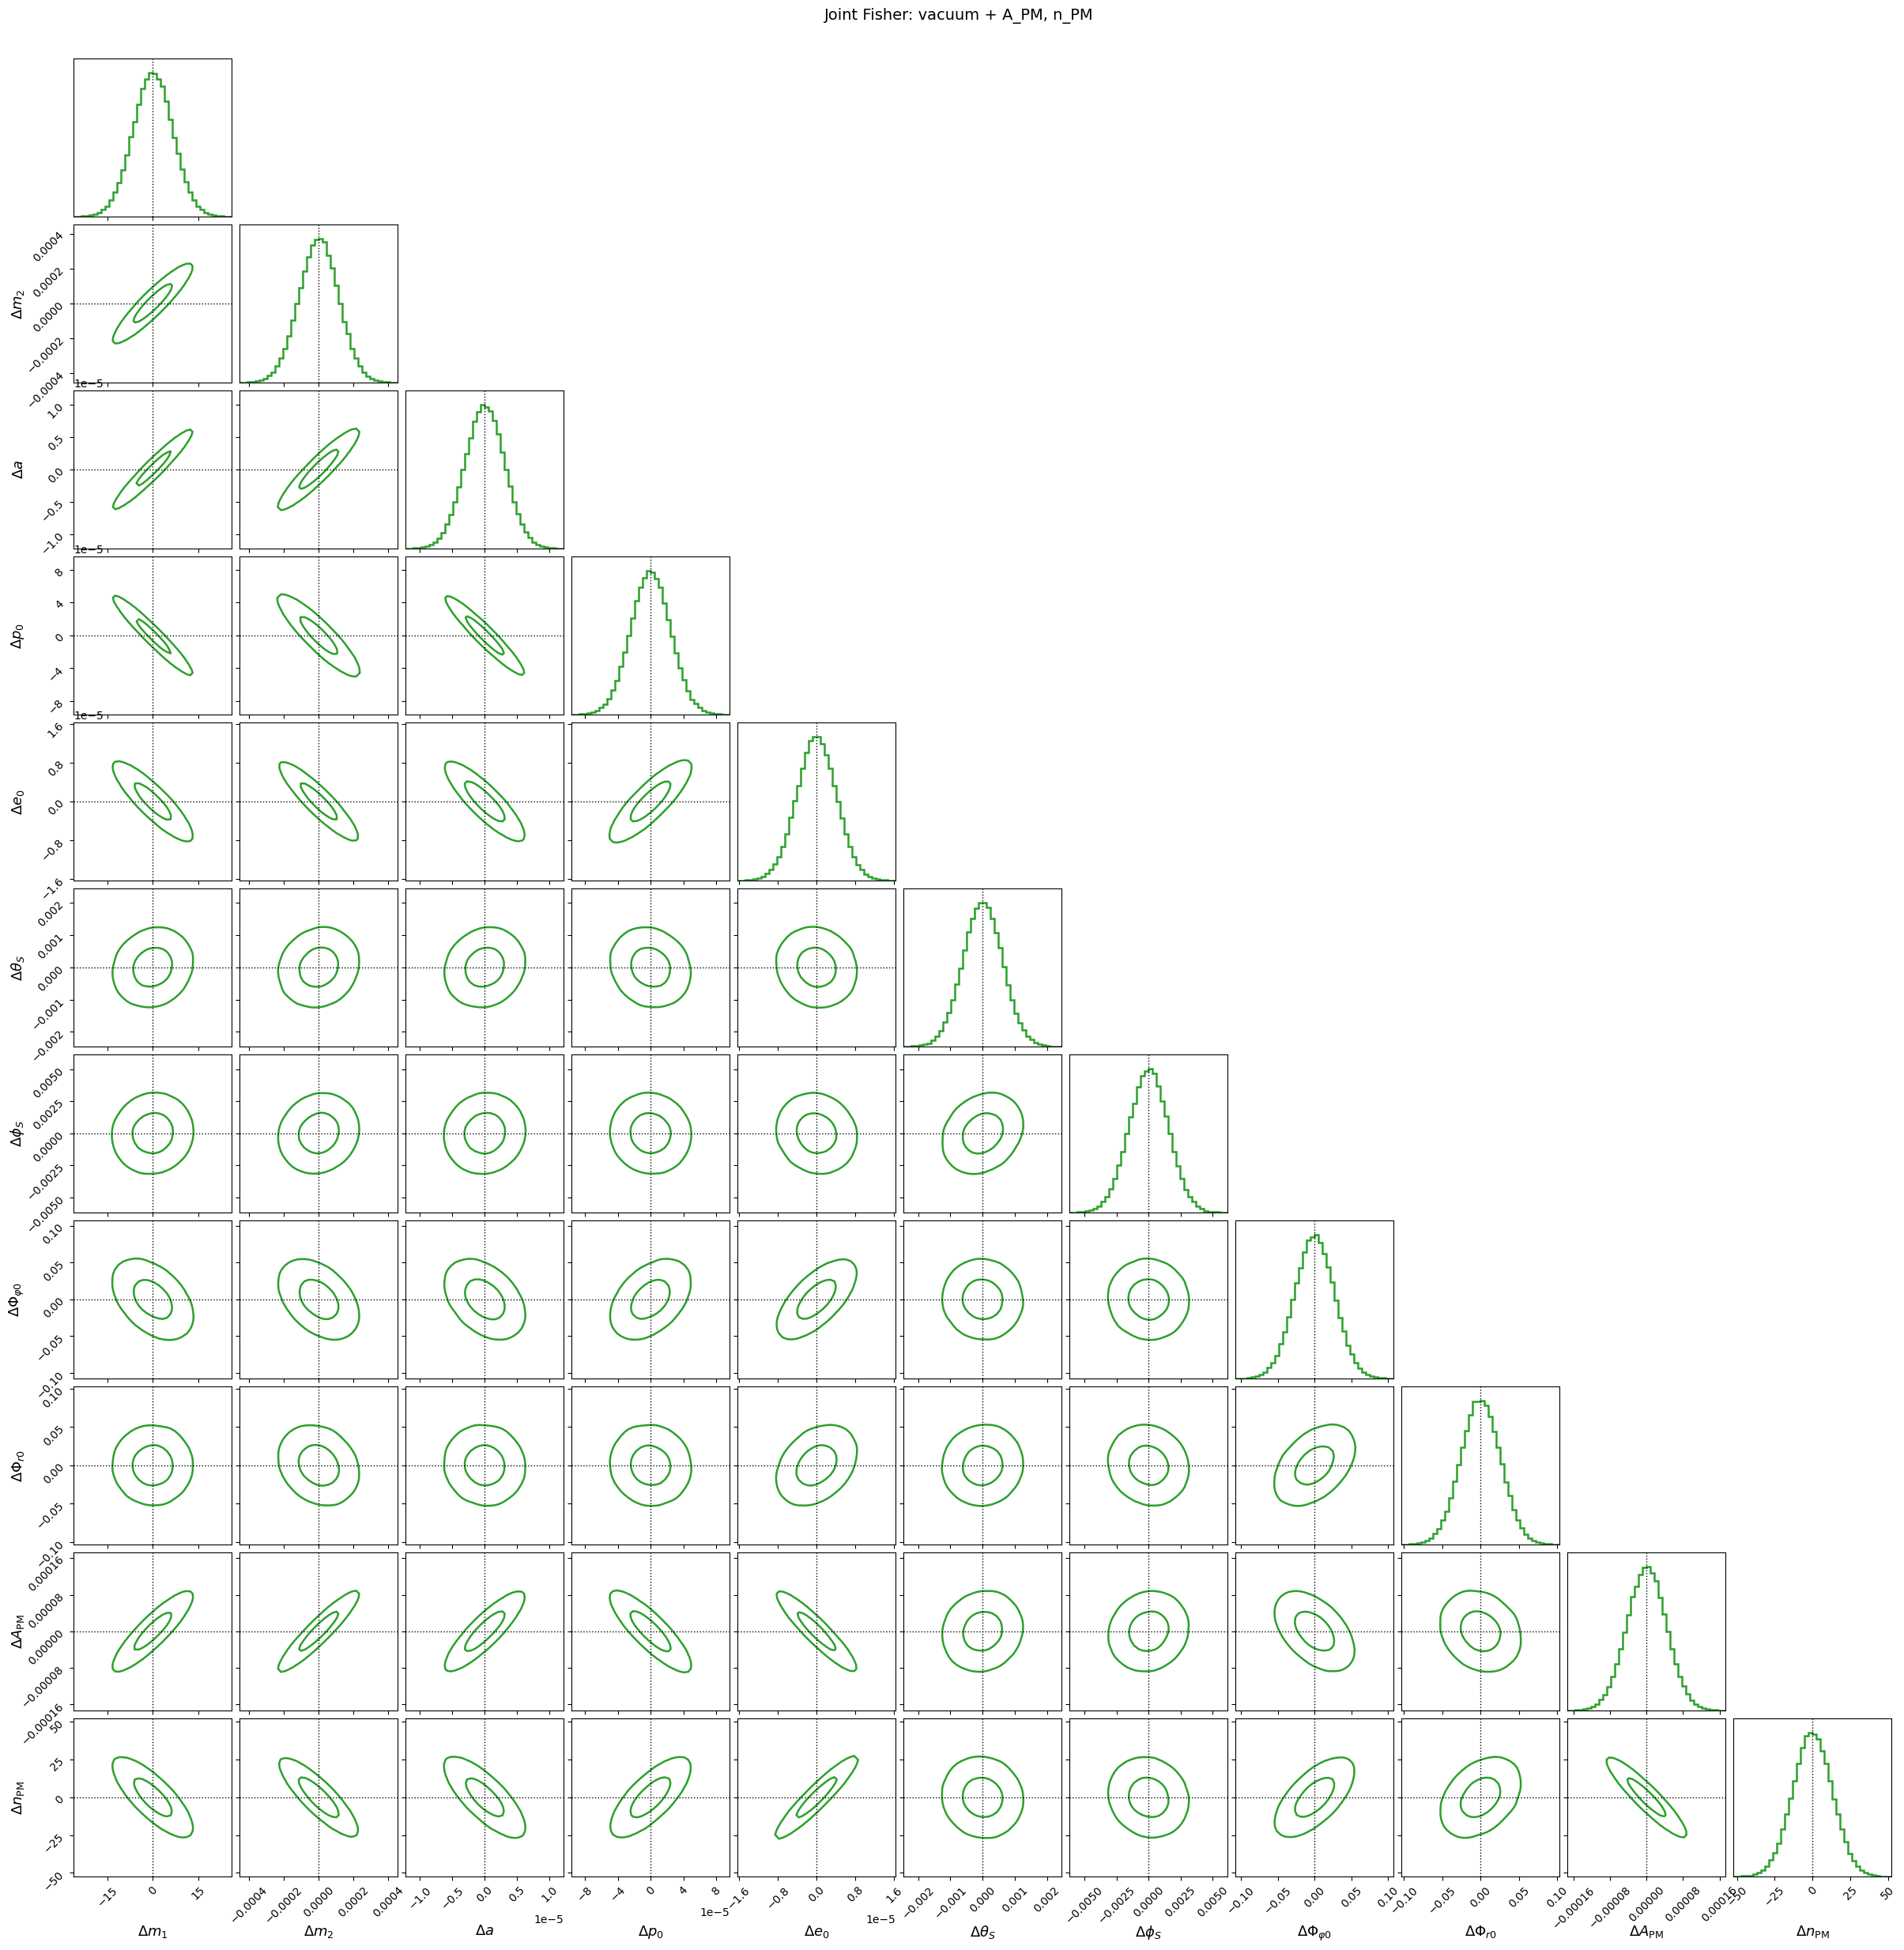


           |      A_PM |      n_PM
-------------------------------------
        m1 |    0.9131 |   -0.8108
        m2 |    0.9622 |   -0.8819
         a |    0.8990 |   -0.7904
        p0 |   -0.8780 |    0.7682
        e0 |   -0.9569 |    0.9694
        qS |    0.0976 |   -0.0666
      phiS |    0.1110 |   -0.1110
  Phi_phi0 |   -0.5032 |    0.6663
    Phi_r0 |   -0.1952 |    0.3739


In [15]:
# The full joint posterior, vacuum + free environmental parameters, so the correlations that
# drive the degradation above are visible directly.
draw_full = rng.multivariate_normal(np.zeros(len(PARAMS_ENV)), cov_env_free, size=NSAMP)
sigma_full = np.sqrt(np.diag(cov_env_free))
range_full = [(-4.0 * s, 4.0 * s) for s in sigma_full]

fig = corner.corner(draw_full, labels=LABELS_ENV, range=range_full,
                    levels=(0.393, 0.865), smooth=1.0, bins=40, color="C2",
                    plot_datapoints=False, plot_density=False, fill_contours=False,
                    hist_kwargs=dict(density=True, lw=1.8, color="C2"),
                    contour_kwargs=dict(linewidths=1.8, colors="C2"),
                    label_kwargs=dict(fontsize=13))
corner.overplot_lines(fig, np.zeros(len(PARAMS_ENV)), color="k", ls=":", lw=1.0)
fig.suptitle(f"Joint Fisher: vacuum + {', '.join(ENV_FREE)}", fontsize=14, y=1.01)

fig.savefig("corner_env_joint.png", dpi=140, bbox_inches="tight")
print("[PLOT] written corner_env_joint.png")
plt.show()

# Correlation coefficients between each free environmental parameter and the vacuum parameters.
corr = cov_env_free / np.outer(sigma_full, sigma_full)
print(f"\n{'':>10} | " + " | ".join(f"{p:>9}" for p in ENV_FREE))
print("-" * (13 + 12 * len(ENV_FREE)))
for i, p in enumerate(PARAMS_9):
    print(f"{p:>10} | " + " | ".join(f"{corr[i, n9 + j]:>9.4f}" for j in range(len(ENV_FREE))))

## 10. Iterated CV bias

The injected signal is the **environmental** waveform; the templates do not know about the
environment. Two recovery models:

| model | free parameters | template |
|---|---|---|
| `0PA`      | the 9 of `PARAMS_9`      | no deviation, no environment |
| `0PA + PN` | those 9 plus `C_p, C_e`  | 2.5PN additive deviation on pdot/edot |

Each is fitted by the same LM-damped Cutler-Vallisneri iteration used in the grid runs:
`dtheta = Gamma^-1 <dh|s-h>` as a Gauss-Newton step, damped with Levenberg-Marquardt and
Nielsen gain-ratio lambda updates, with a Nelder-Mead escape if the climb stalls short of
the overlap target.

The `0PA` climb starts from the injected truth. The `PN` climb starts from the `0PA` best
fit with `C_p = C_e = 0`, which guarantees the deviation model can never end below `0PA`.

In [16]:
# Same control values as the grid runs.
OVERLAP_TARGET = 0.9999999999
LAMBDA0, LM_MAX_ITERS, MAX_INNER, REL_TOL = 1e-2, 150, 30, 1e-9
NM_MAXITER, NM_STEP = 1000, 2.0
RECOMPUTE_DELTAS_EVERY = 5

PARAMS_11 = PARAMS_9 + ["C_p", "C_e"]
LABELS_11 = LABELS_9 + [r"$\Delta C_p$", r"$\Delta C_e$"]

# The injected signal: environment on. Templates below always have environment off.
signal = waveform_env


def template_tail(vec, model_params):
    """SuperKludge tail for a template: never environmental, PN only if the model carries it."""
    dev = dict(zip(model_params, vec))
    on = ("C_p" in dev) or ("C_e" in dev)
    return [chi2, evolve_1PA, evolve_primary, evolve_2PA,
            on, dev.get("C_p", 0.0), dev.get("C_e", 0.0),
            False, 0.0, 0.0, 0.0, 0.0]


def template_apa(vec, model_params):
    """The same tail as a dict for SEF. Keys must match param_names for the free deviations."""
    dev = dict(zip(model_params, vec))
    on = ("C_p" in dev) or ("C_e" in dev)
    apa = env_apa(False)
    apa.update(deviation_included=on, C_p=dev.get("C_p", 0.0), C_e=dev.get("C_e", 0.0))
    return apa


def build_ctx(model_params):
    """Everything the CV iteration needs for one recovery model."""

    def make0(vec):
        p = dict(source_params)
        p.update({n: v for n, v in zip(model_params, vec) if n in param_names_14})
        args = [p[n] for n in param_names_14] + template_tail(vec, model_params)
        return xp.array(waveform_response(*args))[0:nchannels, :]

    def ov(vec):
        h = make0(vec)
        return ip(signal, h) / np.sqrt(ip(signal, signal) * ip(h, h))

    def chi2r(vec):
        try:
            r = signal - make0(vec)
            return ip(r, r)
        except Exception:
            return 1e30

    def fisher_derivs(vec, dl):
        wp = {n: source_params[n] for n in param_names_14}
        wp.update({n: v for n, v in zip(model_params, vec) if n in param_names_14})
        F = sef(wave_params=wp, param_names=model_params,
                add_param_args=template_apa(vec, model_params),
                deltas=dl, freq_mask=freq_mask,
                live_dangerously=False, stability_plot=False,
                der_order=DER_ORDER, Ndelta=(NDELTA if dl is None else None),
                return_derivatives=True)
        return np.asarray(F[-1], dtype=float), xp.array(F[0]), sef.deltas

    return dict(make0=make0, ov=ov, chi2r=chi2r, ip=ip, s=signal,
                fisher_derivs=fisher_derivs, params=model_params)

In [17]:
def lm_climb(ctx, theta0, tag=""):
    ov, chi2r, fisher_derivs, s, ip_, make0 = (ctx["ov"], ctx["chi2r"], ctx["fisher_derivs"],
                                               ctx["s"], ctx["ip"], ctx["make0"])
    npar = len(theta0)
    cur = np.array(theta0, dtype=float)
    lam, nu, dl, sigma = LAMBDA0, 2.0, None, np.ones(npar)
    for it in range(LM_MAX_ITERS):
        if it % RECOMPUTE_DELTAS_EVERY == 0:
            dl = None
        G, dH, deltas = fisher_derivs(cur, dl)
        if dl is None:
            dl = deltas
        h = make0(cur)
        r = s - h
        g = np.array([ip_(dH[j], r) for j in range(npar)])
        sigma = np.sqrt(np.abs(np.diag(fishinv(cur[0], G, index_of_M=0))))
        c0 = ip_(r, r)
        ovc = ip_(s, h) / np.sqrt(ip_(s, s) * ip_(h, h))
        if ovc > OVERLAP_TARGET:
            break
        dvec = np.abs(np.diag(G)) + 1e-30
        delta, ok, rel = np.zeros(npar), False, 0.0
        for _ in range(MAX_INNER):
            try:
                delta = np.linalg.solve(G + lam * np.diag(dvec), g)
            except np.linalg.LinAlgError:
                lam *= nu; nu *= 2.0; continue
            pred = float(delta @ (g + lam * dvec * delta))
            rho = (c0 - chi2r(cur + delta)) / pred if pred > 0 else -1.0
            if rho > 0.0:
                lam *= max(1.0 / 3.0, 1.0 - (2.0 * rho - 1.0) ** 3); nu = 2.0
                rel = (c0 - chi2r(cur + delta)) / c0; ok = True; break
            lam *= nu; nu *= 2.0
        print(f"    CV{tag} it {it:>3} lam={lam:.1e} ov={ovc:.10f} chi2={c0:.3e} rel={rel:.1e}",
              flush=True)
        if not ok:
            break
        cur = cur + delta
        if rel < REL_TOL:
            break
    return cur, ov(cur), sigma


def nm_refine(ctx, theta0, sigma, maxiter):
    chi2r, ov = ctx["chi2r"], ctx["ov"]
    n = len(theta0)
    simplex = np.vstack([np.zeros(n)] + [NM_STEP * np.eye(n)[i] for i in range(n)])
    res = minimize(lambda x: chi2r(theta0 + x * sigma), np.zeros(n), method="Nelder-Mead",
                   options=dict(initial_simplex=simplex, maxiter=maxiter,
                                xatol=1e-4, fatol=1e-4, adaptive=True))
    cand = theta0 + res.x * sigma
    ok = ov(cand) > ov(theta0)
    print(f"    NM  nfev={res.nfev} ov {ov(theta0):.10f} -> {ov(cand):.10f} (accepted={ok})",
          flush=True)
    return cand if ok else theta0


def cv_from(ctx, tag, start):
    theta = np.array(start, dtype=float)
    print(f"    start overlap = {ctx['ov'](theta):.10f}", flush=True)
    theta, ov1, sigma = lm_climb(ctx, theta, tag=f" {tag}#1")
    if ov1 < OVERLAP_TARGET:
        theta = nm_refine(ctx, theta, sigma, NM_MAXITER)
        theta, ov1, sigma = lm_climb(ctx, theta, tag=f" {tag}#2")
    return dict(ov_start=float(ctx["ov"](start)), ov_final=float(ctx["ov"](theta)),
                chi2=float(ctx["chi2r"](theta)), params=theta.copy(),
                start=np.array(start, dtype=float))

## 11. Run the two recoveries

In [18]:
truth_9 = np.array([source_params[n] for n in PARAMS_9], dtype=float)
truth_11 = np.concatenate([truth_9, [0.0, 0.0]])       # the injection carries no PN deviation

t_start = time.time()

print("=" * 78)
print("0PA  (9 params, seeded at the injected truth)")
ctx_0pa = build_ctx(PARAMS_9)
fit_0pa = cv_from(ctx_0pa, "0PA/from_truth", truth_9)

print("=" * 78)
print("0PA + PN  (11 params, seeded at the injected truth)")
ctx_pn = build_ctx(PARAMS_11)
fit_pn = cv_from(ctx_pn, "PN/injected", np.concatenate([truth_9, [0.0, 0.0]]))

print("=" * 78)
print(f"[INFO] both CV climbs took {time.time() - t_start:.1f} s")

0PA  (9 params, seeded at the injected truth)


    start overlap = 0.4999340068
Body is not plunging, Fisher should be stable.
waveform shape: (2, 21076828)
Computing SNR for parameters: (np.float64(1500000.0), np.float64(50.0), np.float64(0.9), np.float64(12.0), np.float64(0.2), 1.0, 1.5, np.float64(0.2), np.float64(0.2), 0.8, 0.8, np.float64(0.3), 0.5, np.float64(0.5), 0.0, False, False, False, False, 0.0, 0.0, False, 2.88e-05, 8.0, 0, 0)
Waveform Generated. SNR: 374.7883766504489
calculating stable deltas...
Time taken to compute stable deltas is 53.28026342391968 seconds
calculating Fisher matrix...
Finished derivatives
Calculated Fisher is *atleast* positive-definite.
Time taken to compute FM is 5.036292314529419 seconds
    CV 0PA/from_truth#1 it   0 lam=3.3e-03 ov=0.4999340068 chi2=1.313e+05 rel=8.5e-01
Body is not plunging, Fisher should be stable.
waveform shape: (2, 21076828)
Computing SNR for parameters: (np.float64(1500000.0069499062), np.float64(49.99999144185329), np.float64(0.9000003916611589), np.float64(12.00000010

In [19]:
# Copy-ready results: full parameter vectors with overlap and chi2 together.
mism_0pa = 1.0 - fit_0pa["ov_final"]
mism_pn = 1.0 - fit_pn["ov_final"]

print(f"injected mismatch vs a GR template at truth : {1 - overlap:.6e}")
print(f"0PA      overlap = {fit_0pa['ov_final']:.12f}   mismatch = {mism_0pa:.6e}   chi2 = {fit_0pa['chi2']:.6e}")
print(f"0PA+PN   overlap = {fit_pn['ov_final']:.12f}   mismatch = {mism_pn:.6e}   chi2 = {fit_pn['chi2']:.6e}")
print(f"PN gain over 0PA (mismatch ratio) = {mism_0pa / max(mism_pn, 1e-300):.2f}x")

print("\nx_bf[0PA]    =", np.array2string(fit_0pa["params"], precision=10, separator=", ", max_line_width=200))
print("x_bf[0PA+PN] =", np.array2string(fit_pn["params"], precision=10, separator=", ", max_line_width=200))
print("x_true       =", np.array2string(truth_11, precision=10, separator=", ", max_line_width=200))

bias_0pa = fit_0pa["params"] - truth_9
bias_pn = fit_pn["params"] - truth_11

print(f"\n{'param':>10} | {'truth':>16} | {'0PA bias':>15} | {'0PA+PN bias':>15}")
print("-" * 66)
for i, p in enumerate(PARAMS_11):
    b0 = f"{bias_0pa[i]:15.6e}" if i < len(PARAMS_9) else " " * 15
    print(f"{p:>10} | {truth_11[i]:16.8g} | {b0} | {bias_pn[i]:15.6e}")

injected mismatch vs a GR template at truth : 5.000660e-01
0PA      overlap = 0.999984343679   mismatch = 1.565632e-05   chi2 = 3.844434e+00
0PA+PN   overlap = 0.999994122125   mismatch = 5.877875e-06   chi2 = 1.447969e+00
PN gain over 0PA (mismatch ratio) = 2.66x

x_bf[0PA]    = [1.4999919636e+06, 4.9999874707e+01, 8.9999605178e-01, 1.2000030707e+01, 2.0000149631e-01, 1.9873825197e-01, 2.0108182514e-01, 2.7585175599e-01, 4.7002835166e-01]
x_bf[0PA+PN] = [ 1.5000004289e+06,  5.0000004712e+01,  8.9999968813e-01,  1.2000002358e+01,  1.9999766849e-01,  1.9930578240e-01,  2.0225038108e-01,  2.8229345733e-01,  4.8285166309e-01, -1.0904527403e-01,
 -3.4075198187e-01]
x_true       = [1.5e+06, 5.0e+01, 9.0e-01, 1.2e+01, 2.0e-01, 2.0e-01, 2.0e-01, 3.0e-01, 5.0e-01, 0.0e+00, 0.0e+00]

     param |            truth |        0PA bias |     0PA+PN bias
------------------------------------------------------------------
        m1 |          1500000 |   -8.036421e+00 |    4.289418e-01
        m2 |   

## 12. CV bias corner plots

Contour widths come from a Fisher recomputed **at each recovered point**, which is what the
CV formalism assumes. Contours are centred on each model's bias, so the dotted lines at zero
mark the injected truth: a contour that does not enclose zero is a bias larger than the
statistical error.

In [20]:
def cov_at(ctx, theta, label):
    t0 = time.time()
    G, _, _ = ctx["fisher_derivs"](np.asarray(theta, dtype=float), None)
    G = 0.5 * (G + G.T)
    Cm = fishinv(theta[0], G, index_of_M=0)
    Cm = 0.5 * (Cm + Cm.T)
    ev = np.linalg.eigvalsh(Cm)
    if ev.min() <= 0:
        print(f"[WARN] {label}: covariance not positive definite, min eigenvalue = {ev.min():.3e}")
    print(f"[FISH] {label}: cond = {np.linalg.cond(G):.3e}, {time.time() - t0:.1f} s")
    return Cm


cov_0pa = cov_at(ctx_0pa, fit_0pa["params"], "0PA  @ best fit")
cov_pn = cov_at(ctx_pn, fit_pn["params"], "0PA+PN @ best fit")

sig_0pa = np.sqrt(np.diag(cov_0pa))
sig_pn = np.sqrt(np.diag(cov_pn))

print(f"\n{'param':>10} | {'0PA bias/sigma':>15} | {'0PA+PN bias/sigma':>18}")
print("-" * 50)
for i, p in enumerate(PARAMS_11):
    b0 = f"{bias_0pa[i] / sig_0pa[i]:15.4f}" if i < len(PARAMS_9) else " " * 15
    print(f"{p:>10} | {b0} | {bias_pn[i] / sig_pn[i]:18.4f}")

Body is not plunging, Fisher should be stable.
waveform shape: (2, 21076828)
Computing SNR for parameters: (np.float64(1499991.9635788791), np.float64(49.99987470740578), np.float64(0.8999960517818704), np.float64(12.000030707290321), np.float64(0.20000149630738354), 1.0, 1.5, np.float64(0.1987382519652651), np.float64(0.2010818251414561), 0.8, 0.8, np.float64(0.27585175599244566), 0.5, np.float64(0.47002835165679513), 0.0, False, False, False, False, 0.0, 0.0, False, 2.88e-05, 8.0, 0, 0)
Waveform Generated. SNR: 348.3714442096491
calculating stable deltas...
Time taken to compute stable deltas is 53.26938033103943 seconds
calculating Fisher matrix...
Finished derivatives
Calculated Fisher is *atleast* positive-definite.
Time taken to compute FM is 4.98756742477417 seconds
[FISH] 0PA  @ best fit: cond = 1.056e+18, 61.4 s
Body is not plunging, Fisher should be stable.
waveform shape: (2, 21076828)
Computing SNR for parameters: (np.float64(1500000.4289417558), np.float64(50.0000047120396

[PLOT] written corner_cv_bias_9.png


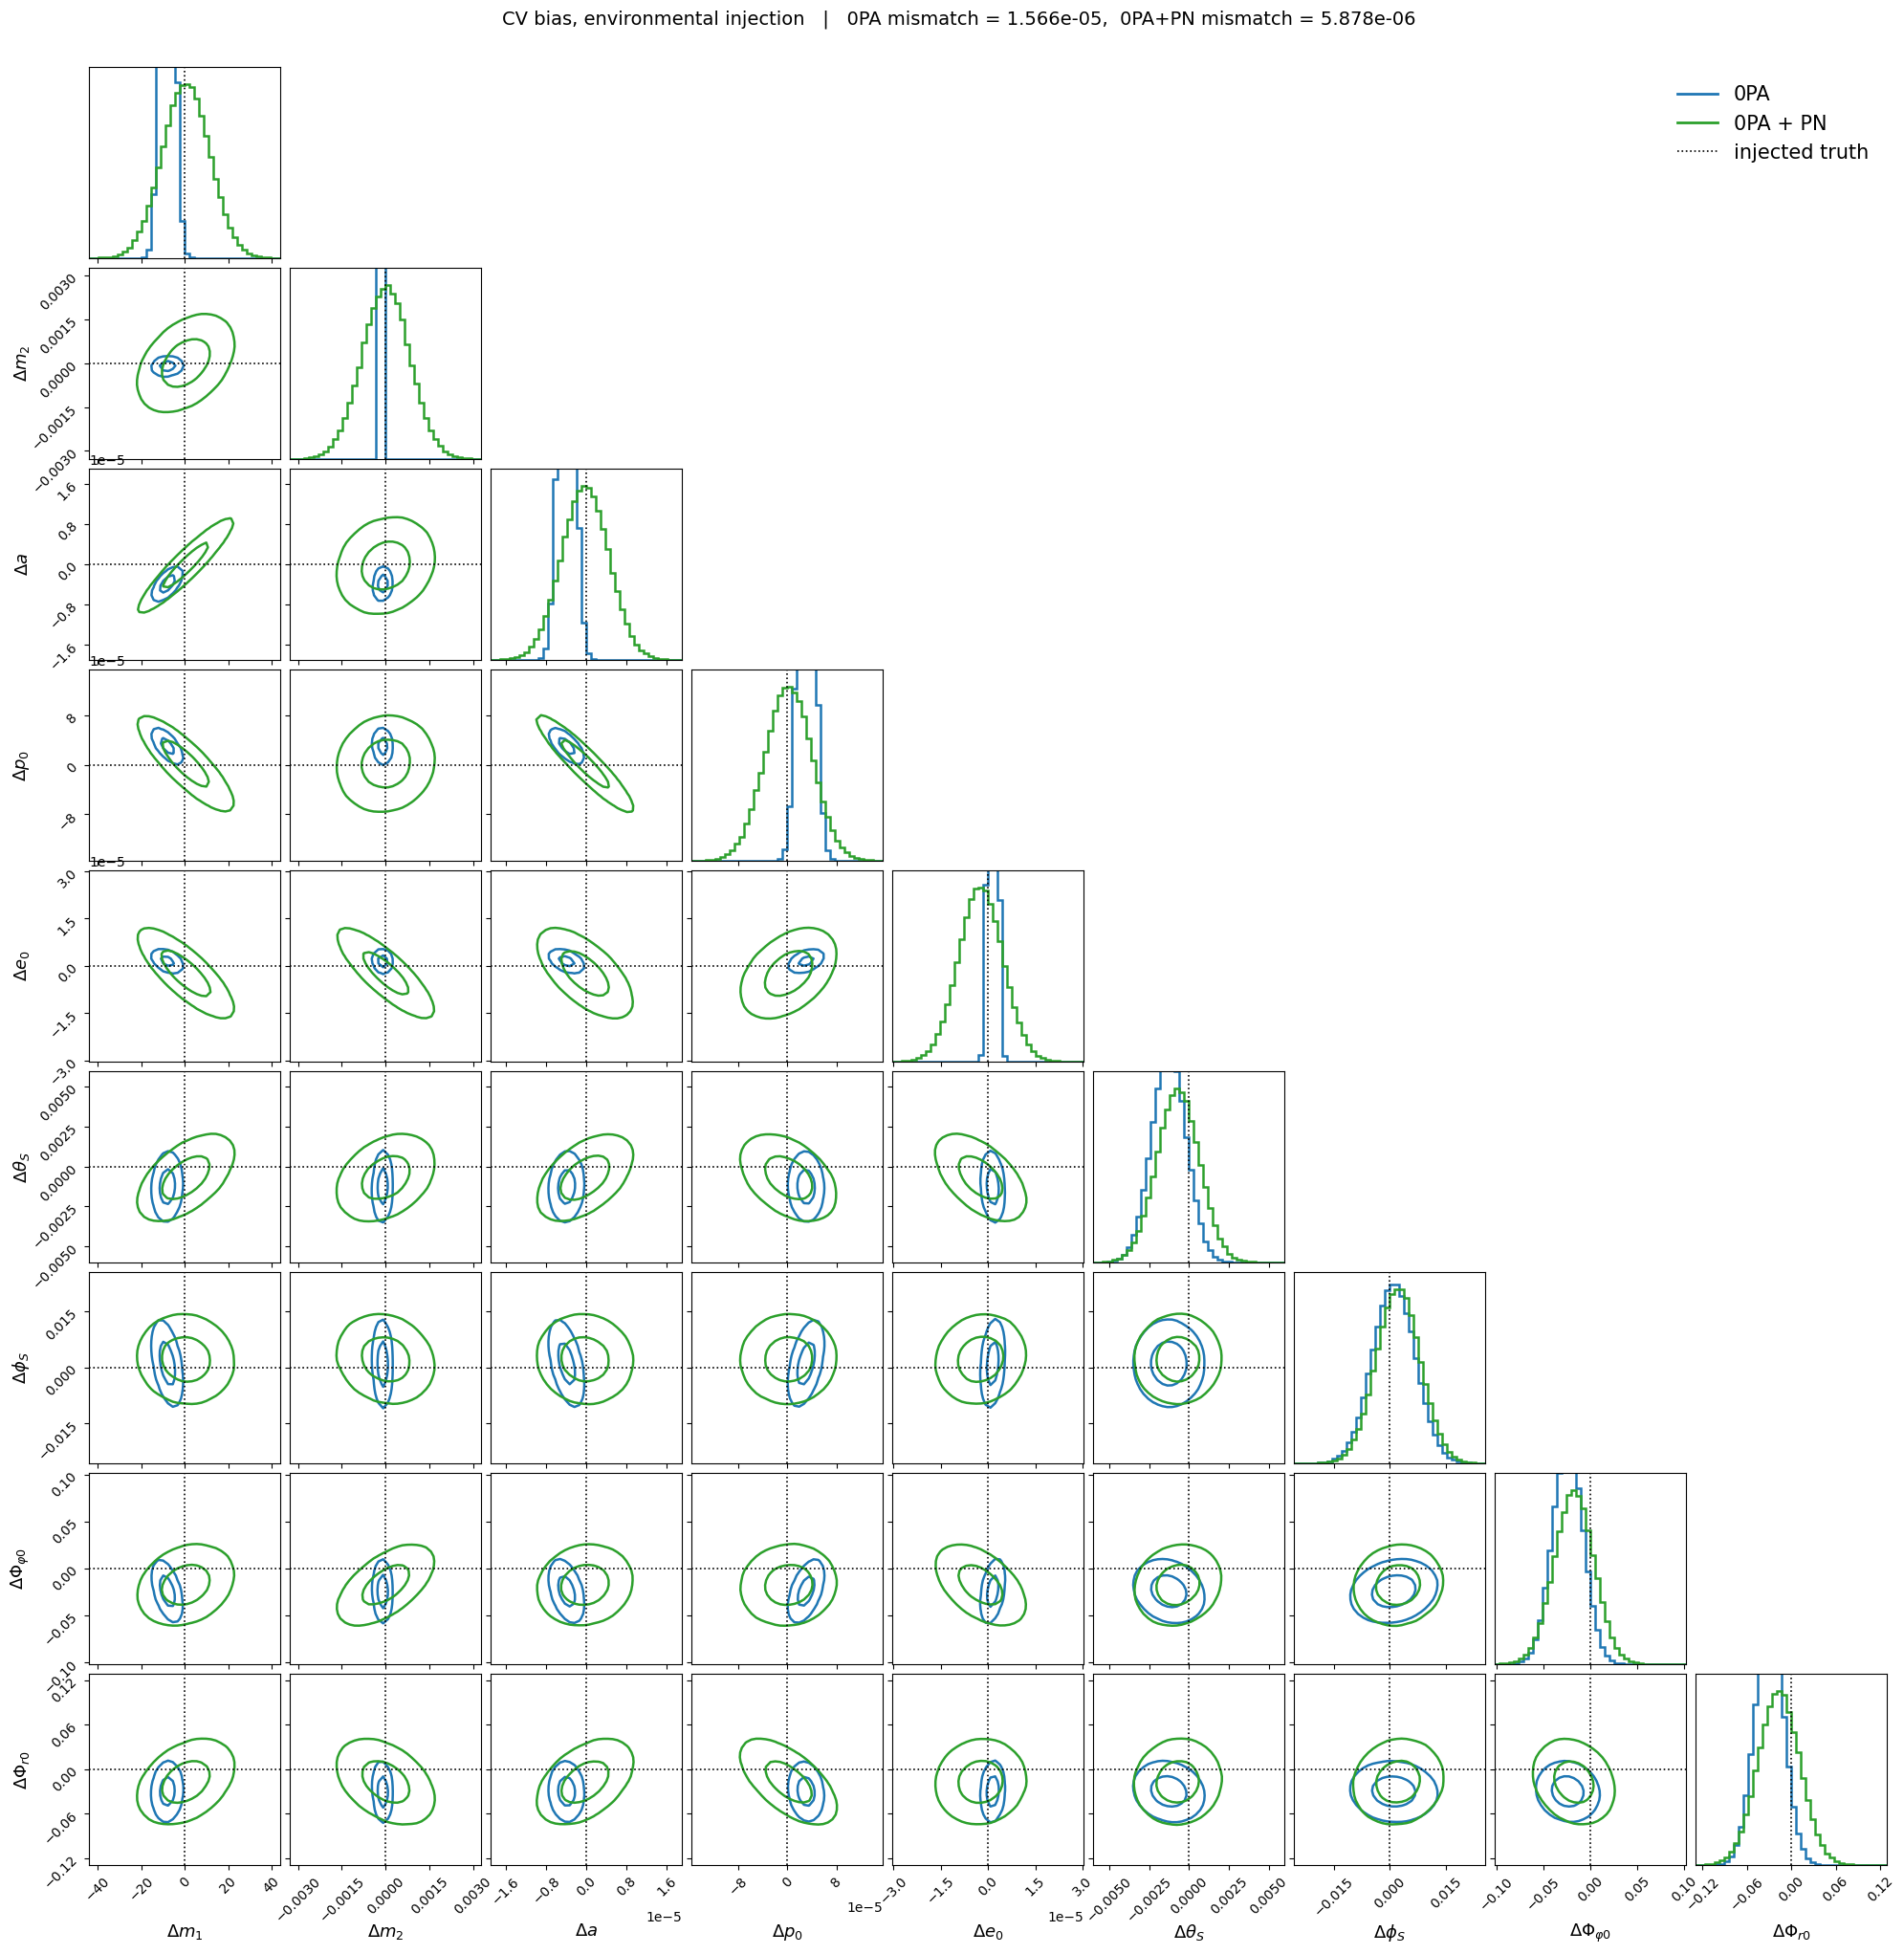

In [21]:
def bias_corner(entries, labels, fname, title):
    """entries: list of (label, colour, bias vector, covariance)."""
    ndim = len(labels)
    rng_ = np.random.default_rng(7)
    draws = [(c, rng_.multivariate_normal(b, cv, size=NSAMP)) for _, c, b, cv in entries]

    span = np.zeros(ndim)
    for _, c, b, cv in entries:
        span = np.maximum(span, np.abs(b) + 4.0 * np.sqrt(np.diag(cv)))
    rng_lim = [(-s, s) for s in span]

    def kw(color):
        return dict(labels=labels, range=rng_lim, levels=(0.393, 0.865),
                    smooth=1.0, bins=40, color=color,
                    plot_datapoints=False, plot_density=False, fill_contours=False,
                    hist_kwargs=dict(density=True, lw=1.8, color=color),
                    contour_kwargs=dict(linewidths=1.8, colors=color),
                    label_kwargs=dict(fontsize=13))

    fig = None
    for color, d in draws:
        fig = corner.corner(d, **kw(color)) if fig is None else corner.corner(d, fig=fig, **kw(color))

    corner.overplot_lines(fig, np.zeros(ndim), color="k", ls=":", lw=1.2)
    handles = [plt.Line2D([], [], color=c, lw=2, label=lab) for lab, c, _, _ in entries]
    handles.append(plt.Line2D([], [], color="k", ls=":", lw=1.2, label="injected truth"))
    fig.legend(handles=handles, loc="upper right", frameon=False, fontsize=15,
               bbox_to_anchor=(0.98, 0.98))
    fig.suptitle(title, fontsize=14, y=1.01)
    fig.savefig(fname, dpi=140, bbox_inches="tight")
    print(f"[PLOT] written {fname}")
    return fig


# (a) the two models on the 9 common parameters
bias_corner(
    [("0PA", "C0", bias_0pa, cov_0pa),
     ("0PA + PN", "C2", bias_pn[:9], cov_pn[:9, :9])],
    LABELS_9, "corner_cv_bias_9.png",
    f"CV bias, environmental injection   |   0PA mismatch = {mism_0pa:.3e},  "
    f"0PA+PN mismatch = {mism_pn:.3e}")
plt.show()

[PLOT] written corner_cv_bias_11.png


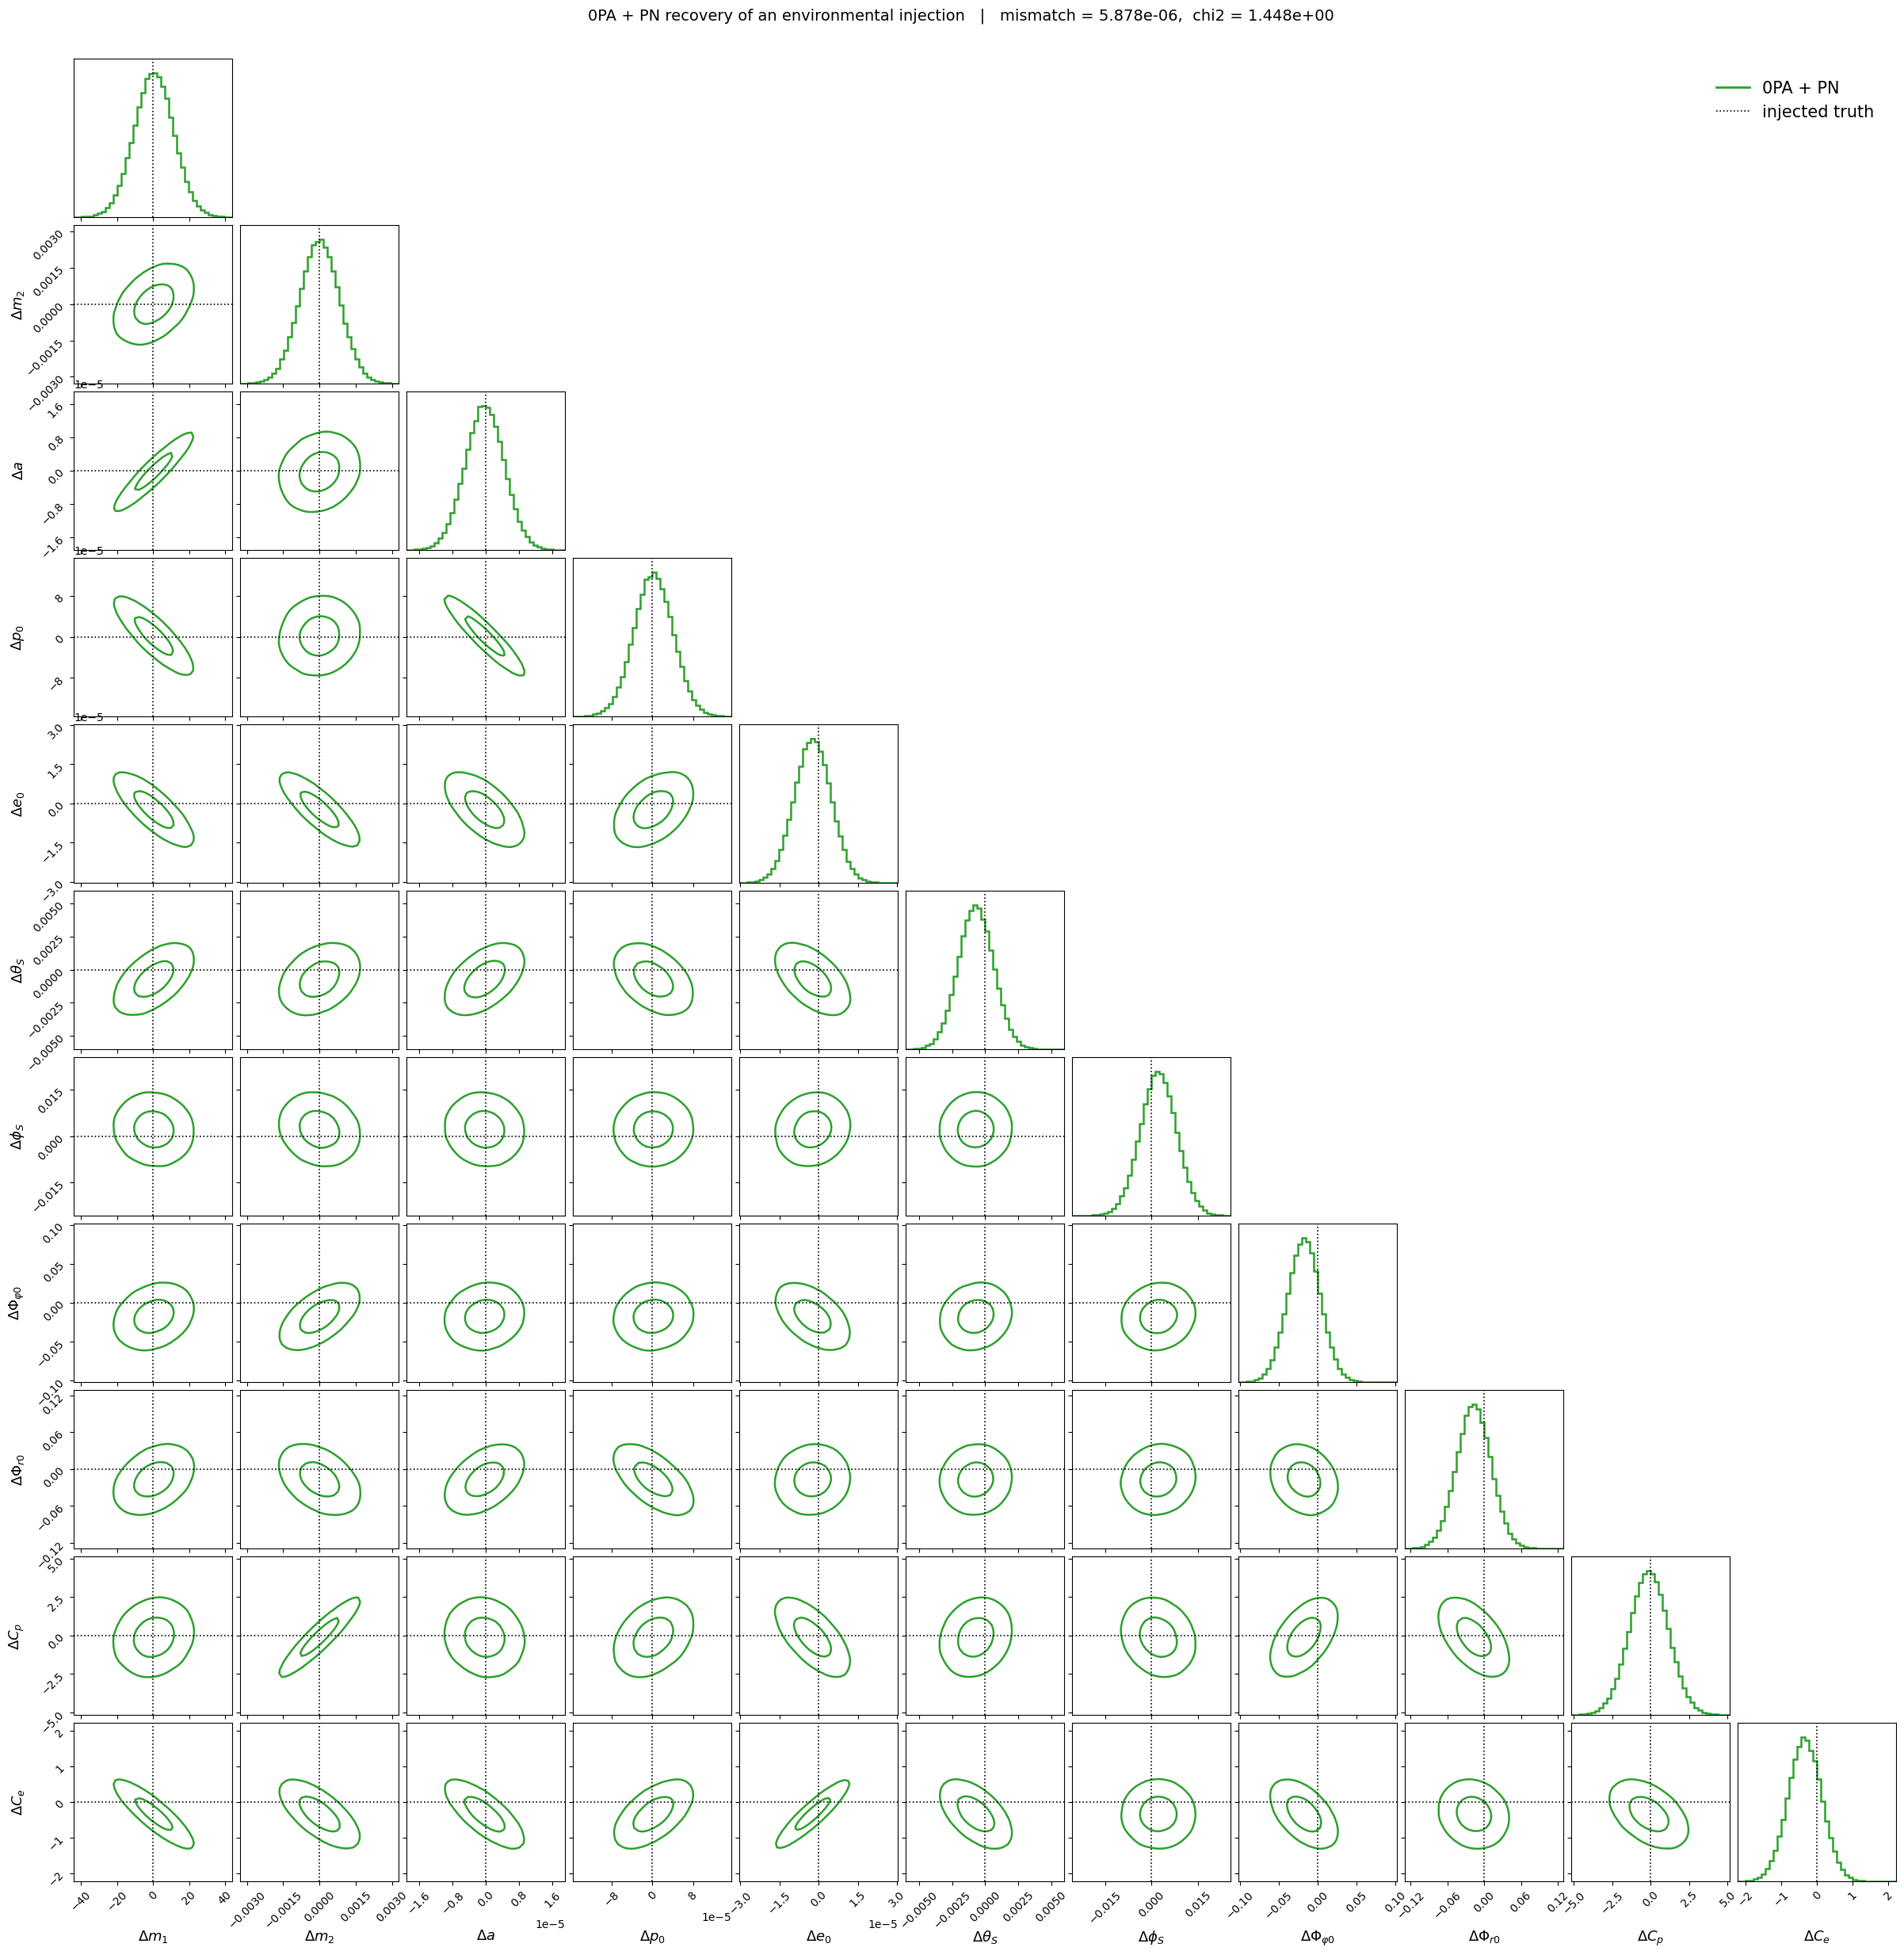

In [22]:
# (b) the PN fit on its own, including the deviation parameters
bias_corner(
    [("0PA + PN", "C2", bias_pn, cov_pn)],
    LABELS_11, "corner_cv_bias_11.png",
    f"0PA + PN recovery of an environmental injection   |   "
    f"mismatch = {mism_pn:.3e},  chi2 = {fit_pn['chi2']:.3e}")
plt.show()

## 13. Summary

In [23]:
summary = dict(
    source_params=source_params,
    environmental=dict(A_PM=A_PM, n_PM=n_PM, A_GC=A_GC, n_GC=n_GC),
    config=dict(T=T, T_plunge=T_plunge, dt=dt, nchannels=nchannels, chi2=chi2,
                f_min=F_MIN, f_max=F_MAX, n_bins_kept=n_kept,
                Ndelta=NDELTA, der_order=DER_ORDER, use_gpu=use_gpu),
    snr_gr=snr_gr, snr_env=snr_env,
    overlap=overlap, mismatch=mismatch, chi2_residual=chi2_resid,
    dPhi_phi=dPhi_phi, dPhi_r=dPhi_r,
    params=PARAMS_9,
    sigma_gr=sigma_gr.tolist(), sigma_env=sigma_env.tolist(),
    cond_fisher_gr=float(np.linalg.cond(fisher_gr)),
    cond_fisher_env=float(np.linalg.cond(fisher_env)),
    fisher_gr=fisher_gr.tolist(), fisher_env=fisher_env.tolist(),
    cov_gr=cov_gr.tolist(), cov_env=cov_env.tolist(),
    cv=dict(
        params_9=PARAMS_9, params_11=PARAMS_11,
        truth_11=truth_11.tolist(),
        zero_pa=dict(ov=fit_0pa["ov_final"], chi2=fit_0pa["chi2"],
                     x_bf=fit_0pa["params"].tolist(), bias=bias_0pa.tolist(),
                     sigma=sig_0pa.tolist(), cov=cov_0pa.tolist()),
        zero_pa_pn=dict(ov=fit_pn["ov_final"], chi2=fit_pn["chi2"],
                        x_bf=fit_pn["params"].tolist(), bias=bias_pn.tolist(),
                        sigma=sig_pn.tolist(), cov=cov_pn.tolist()),
        pn_gain=mism_0pa / max(mism_pn, 1e-300),
    ),
)

with open("results_env_test.json", "w") as f:
    json.dump(summary, f, indent=2)

print(json.dumps({k: v for k, v in summary.items()
                  if k not in ("fisher_gr", "fisher_env", "cov_gr", "cov_env")}, indent=2))
print("\n[DONE] written results_env_test.json")

{
  "source_params": {
    "m1": 1500000.0,
    "m2": 50,
    "a": 0.9,
    "p0": 12,
    "e0": 0.2,
    "xI0": 1.0,
    "dist": 1.5,
    "qS": 0.2,
    "phiS": 0.2,
    "qK": 0.8,
    "phiK": 0.8,
    "Phi_phi0": 0.3,
    "Phi_theta0": 0.5,
    "Phi_r0": 0.5,
    "chi2": 0.0,
    "evolve_1PA": false,
    "evolve_primary": false,
    "evolve_2PA": false,
    "deviation_included": false,
    "C_p": 0.0,
    "C_e": 0.0,
    "environmental_included": true,
    "A_PM": 2.88e-05,
    "n_PM": 8.0,
    "A_GC": 0,
    "n_GC": 0
  },
  "environmental": {
    "A_PM": 2.88e-05,
    "n_PM": 8.0,
    "A_GC": 0,
    "n_GC": 0
  },
  "config": {
    "T": 3.339363786988724,
    "T_plunge": 3.3730947343320445,
    "dt": 5,
    "nchannels": 2,
    "chi2": 0.0,
    "f_min": 1e-05,
    "f_max": 0.1,
    "n_bins_kept": 10537360,
    "Ndelta": 12,
    "der_order": 8,
    "use_gpu": true
  },
  "snr_gr": 374.78837664916546,
  "snr_env": 348.57641487795394,
  "overlap": 0.4999340068297765,
  "mismatch": 0.500